# Nunn and Wantchekon (2011), Table 3: double machine learning estimates

This notebook estimates a partially linear double machine learning (DML) analogue of Table 3 in Nunn and Wantchekon (2011), *The Origins of Mistrust in Africa*. The treatment is ancestral slave-export exposure, `ln_export_area`, and the outcomes are five measures of present-day trust. Flexible nuisance models adjust for the observed Table 3 controls; they do not remove bias from unobserved confounding.

## Published Table 3 benchmarks

The published OLS coefficients provide reference points rather than targets for the DML estimates.

| Outcome | Published OLS coefficient |
|---|---:|
| Trust relatives | -0.178 |
| Trust neighbors | -0.202 |
| Trust local council | -0.129 |
| Intragroup trust | -0.188 |
| Intergroup trust | -0.115 |

## 1. Runtime and dependencies

This cell verifies the CUDA runtime, loads the numerical and GPU libraries, and defines conversion, prediction, and fold helpers used throughout the notebook.

In [1]:
from pathlib import Path
import importlib.util
import os
import subprocess
import sys
import warnings

import numpy as np
import pandas as pd


def ensure_colab_gpu_libraries(auto_install=True):
    """Verify CUDA availability and install RAPIDS/cuML if needed."""
    gpu_check = subprocess.run(
        ["nvidia-smi"],
        text=True,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
    )
    print(gpu_check.stdout)
    if gpu_check.returncode != 0:
        raise RuntimeError(
            "No CUDA GPU is visible. In Colab, choose Runtime > Change runtime type > GPU, "
            "then restart and run the notebook again."
        )

    missing = [pkg for pkg in ["cuml", "cudf", "cupy"] if importlib.util.find_spec(pkg) is None]
    if missing:
        if not auto_install:
            raise ImportError(f"Missing GPU packages: {missing}")
        print(f"Installing missing RAPIDS GPU packages: {missing}")
        subprocess.check_call(
            [
                sys.executable,
                "-m",
                "pip",
                "install",
                "--quiet",
                "--extra-index-url=https://pypi.nvidia.com",
                "cudf-cu12",
                "cuml-cu12",
                "cupy-cuda12x",
            ]
        )
        print("RAPIDS installation finished. If the imports below fail, restart the Colab runtime once and rerun.")


ensure_colab_gpu_libraries(auto_install=True)

import cupy as cp
import cudf

from cuml.ensemble import RandomForestRegressor as CuRandomForestRegressor
from cuml.linear_model import ElasticNet as CuElasticNet
try:
    from cuml.linear_model import Lasso as CuLasso
except Exception:
    CuLasso = None

try:
    from cuml.tree import DecisionTreeRegressor as CuDecisionTreeRegressor
    CUML_HAS_DECISION_TREE = True
except Exception:
    CuDecisionTreeRegressor = None
    CUML_HAS_DECISION_TREE = False

from xgboost import XGBRegressor

import torch
import torch.nn as nn

if not torch.cuda.is_available():
    raise RuntimeError("PyTorch cannot see CUDA. Confirm the Colab runtime is set to GPU.")

DEVICE = torch.device("cuda")
print(f"PyTorch device: {torch.cuda.get_device_name(0)}")

from scipy import stats

import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", category=UserWarning)
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)


def as_float32_numpy(X):
    """Convert pandas/cuDF/CuPy inputs to a dense float32 NumPy array for model handoff."""
    if isinstance(X, pd.DataFrame):
        return X.to_numpy(dtype=np.float32)
    if isinstance(X, cudf.DataFrame):
        return X.to_pandas().to_numpy(dtype=np.float32)
    if isinstance(X, cp.ndarray):
        return cp.asnumpy(X).astype(np.float32)
    return np.asarray(X, dtype=np.float32)


def to_numpy_1d(values):
    """Return model predictions as a one-dimensional CPU NumPy array for DML residualization."""
    if isinstance(values, cp.ndarray):
        values = cp.asnumpy(values)
    elif hasattr(values, "to_numpy"):
        values = values.to_numpy()
    elif hasattr(values, "values"):
        values = values.values
    return np.asarray(values, dtype=float).reshape(-1)


def mse(y_true, y_pred):
    """Mean squared error without importing CPU ML estimators from scikit-learn."""
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return float(np.mean((y_true - y_pred) ** 2))


def assert_xgboost_cuda(model):
    """Fail loudly if XGBoost did not configure a CUDA/GPU booster."""
    config = model.get_booster().save_config().lower()
    if "cuda" not in config and "gpu" not in config:
        raise RuntimeError(
            "XGBoost did not report CUDA/GPU in its booster config. "
            "Upgrade xgboost in Colab or use a GPU runtime before running DML."
        )


def iter_kfold_indices(n, n_folds=2, random_state=1211):
    """Small NumPy K-fold splitter to avoid relying on scikit-learn for cross-fitting."""
    rng = np.random.default_rng(random_state)
    indices = rng.permutation(n)
    folds = np.array_split(indices, n_folds)
    for fold in folds:
        test_idx = np.sort(fold)
        train_idx = np.sort(np.setdiff1d(indices, test_idx, assume_unique=False))
        yield train_idx, test_idx

This optional Colab cell mounts Google Drive. Outside Colab, configure the project root in the data-loading cell and skip this cell.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

## 2. Data and project paths

This cell resolves a configurable project root, loads the Stata replication data without converting categorical codes, and verifies the variables required for Table 3.

In [ ]:
PROJECT_ROOT = Path(os.environ.get("ECON_MA_PROJECT_ROOT", Path.cwd())).expanduser().resolve()
DATA_DIR = PROJECT_ROOT / "NUNN_WANTCHEKON_AER_2011_REPLICATION_FILES"
DATA_PATH = DATA_DIR / "Nunn_Wantchekon_AER_2011.dta"
STATA_TABLE_SCRIPT = DATA_DIR / "Trust_OLS_Tables1_3.do"

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Could not find {DATA_PATH.name} under the configured project root. "
        "Set ECON_MA_PROJECT_ROOT to the repository directory."
    )

# Preserve numeric category codes so dummy coding remains explicit and reproducible.
df = pd.read_stata(DATA_PATH, convert_categoricals=False)

print(f"Loaded replication data: {DATA_PATH.name}")
print(f"Dataset shape: {df.shape[0]:,} rows x {df.shape[1]:,} columns")

required_variables = [
    "trust_relatives",
    "trust_neighbors",
    "trust_local_council",
    "intra_group_trust",
    "inter_group_trust",
    "ln_export_area",
    "age",
    "age2",
    "male",
    "urban_dum",
    "education",
    "occupation",
    "religion",
    "living_conditions",
    "district_ethnic_frac",
    "frac_ethnicity_in_district",
    "isocode",
    "malaria_ecology",
    "total_missions_area",
    "explorer_contact",
    "railway_contact",
    "cities_1400_dum",
    "v30",
    "v33",
    "ln_init_pop_density",
    "murdock_name",
    "district",
]

missing_variables = [var for var in required_variables if var not in df.columns]
if missing_variables:
    raise ValueError(f"Missing variables: {missing_variables}")

display(pd.DataFrame([{
    "rows": df.shape[0],
    "columns": df.shape[1],
    "required_variables": len(required_variables),
    "missing_required_variables": len(missing_variables),
}]))

## 3. Outcomes, treatment, controls, and clusters

This cell records the five outcomes, treatment, control blocks, clustering variables, published coefficients, and readable outcome labels used in later tables.

In [4]:
# The five Table 3 trust outcomes.
outcomes = [
    "trust_relatives",
    "trust_neighbors",
    "trust_local_council",
    "intra_group_trust",
    "inter_group_trust",
]

# The paper's ln(1 + slave exports / land area) treatment.
treatment = "ln_export_area"

# Continuous or already-binary controls from Table 3.
continuous_controls = [
    "age",
    "age2",
    "male",
    "urban_dum",
    "district_ethnic_frac",
    "frac_ethnicity_in_district",
    "malaria_ecology",
    "total_missions_area",
    "explorer_contact",
    "railway_contact",
    "cities_1400_dum",
    "v33",
    "ln_init_pop_density",
]

# Table 3 fixed effects and categorical controls.
categorical_controls = [
    "education",
    "occupation",
    "religion",
    "living_conditions",
    "isocode",
    "v30",
]

controls = continuous_controls + categorical_controls

# Two clustering dimensions used in the original Table 3 replication code.
cluster_vars = ["murdock_name", "district"]

original_ols = {
    "trust_relatives": -0.178,
    "trust_neighbors": -0.202,
    "trust_local_council": -0.129,
    "intra_group_trust": -0.188,
    "inter_group_trust": -0.115,
}

outcome_labels = {
    "trust_relatives": "Trust relatives",
    "trust_neighbors": "Trust neighbors",
    "trust_local_council": "Trust local council",
    "intra_group_trust": "Intragroup trust",
    "inter_group_trust": "Intergroup trust",
}

print("Treatment:", treatment)
print("Number of controls before dummy coding:", len(controls))
print("Cluster variables:", cluster_vars)

Treatment: ln_export_area
Number of controls before dummy coding: 19
Cluster variables: ['murdock_name', 'district']


## 4. Outcome-specific analysis samples

The sample builder creates an outcome-specific complete-case sample, dummy-codes categorical controls with an omitted category, and checks that neither outcome nor treatment leaks into the feature matrix.

In [5]:
def prepare_table3_sample(data, outcome):
    '''Build the complete-case Table 3 sample for one outcome.'''
    needed = [outcome, treatment] + controls + cluster_vars
    
    # Drop only observations missing variables needed for this outcome-specific column.
    sample = data[needed].dropna().copy()
    
    # Separate the target, treatment, controls, and cluster identifiers.
    Y = sample[outcome].astype(float).to_numpy()
    D = sample[treatment].astype(float).to_numpy()
    clusters = sample[cluster_vars].astype(str).reset_index(drop=True)
    
    # Convert categorical controls to string before dummy coding so numeric category codes
    # are treated as labels rather than continuous variables.
    X_cont = sample[continuous_controls].astype(float).reset_index(drop=True)
    X_cat = sample[categorical_controls].astype(str).reset_index(drop=True)
    
    # drop_first=True leaves one omitted category for each categorical control.
    X_cat_dummies = pd.get_dummies(X_cat, drop_first=True, dtype=float)
    X = pd.concat([X_cont, X_cat_dummies], axis=1)
    
    # Defensive checks help catch accidental feature leakage.
    assert outcome not in X.columns
    assert treatment not in X.columns
    
    return {
        "outcome": outcome,
        "Y": Y,
        "D": D,
        "X": X,
        "clusters": clusters,
        "n": len(sample),
        "n_ethnicity_clusters": clusters["murdock_name"].nunique(),
        "n_district_clusters": clusters["district"].nunique(),
    }


sample_summary = []
for outcome in outcomes:
    prepared = prepare_table3_sample(df, outcome)
    sample_summary.append(
        {
            "outcome": outcome,
            "N": prepared["n"],
            "X columns after dummy coding": prepared["X"].shape[1],
            "ethnicity clusters": prepared["n_ethnicity_clusters"],
            "district clusters": prepared["n_district_clusters"],
        }
    )

pd.DataFrame(sample_summary)

,outcome,N,X columns after dummy coding,ethnicity clusters,district clusters
0,trust_relatives,16709,90,147,1187
1,trust_neighbors,16679,90,147,1187
2,trust_local_council,15905,91,146,1194
3,intra_group_trust,16636,90,147,1186
4,inter_group_trust,16473,90,147,1184


## 5. Nuisance learners

Six GPU-based learner families estimate the outcome and treatment nuisance functions: lasso, regression tree, boosting, random forest, neural network, and an averaging ensemble. Learners never receive the treatment when predicting the outcome or the outcome when predicting the treatment.

This cell implements the six GPU nuisance learners and factories that create fresh model instances for every fold and nuisance equation.

In [6]:
class CuMLLassoRegressor:
    """GPU lasso-style regression using RAPIDS cuML."""
    def __init__(self, alpha=0.001, max_iter=10_000, random_state=1211):
        self.alpha = alpha
        self.max_iter = max_iter
        self.random_state = random_state

    def fit(self, X, y):
        X_gpu = cudf.DataFrame(as_float32_numpy(X))
        y_gpu = cudf.Series(np.asarray(y, dtype=np.float32))
        if CuLasso is not None:
            self.model_ = CuLasso(alpha=self.alpha, max_iter=self.max_iter, fit_intercept=True)
        else:
            self.model_ = CuElasticNet(alpha=self.alpha, l1_ratio=1.0, max_iter=self.max_iter, fit_intercept=True)
        self.model_.fit(X_gpu, y_gpu)
        return self

    def predict(self, X):
        X_gpu = cudf.DataFrame(as_float32_numpy(X))
        return to_numpy_1d(self.model_.predict(X_gpu))


class CuMLTreeRegressor:
    """GPU regression tree; falls back to one-tree CUDA XGBoost if cuML tree is unavailable."""
    def __init__(self, max_depth=8, min_samples_leaf=5, random_state=1211):
        self.max_depth = max_depth
        self.min_samples_leaf = min_samples_leaf
        self.random_state = random_state

    def fit(self, X, y):
        X_np = as_float32_numpy(X)
        y_np = np.asarray(y, dtype=np.float32)
        if CUML_HAS_DECISION_TREE:
            self.model_ = CuDecisionTreeRegressor(
                max_depth=self.max_depth,
                min_samples_leaf=self.min_samples_leaf,
            )
            self.model_.fit(cudf.DataFrame(X_np), cudf.Series(y_np))
        else:
            self.model_ = XGBRegressor(
                n_estimators=1,
                max_depth=self.max_depth,
                learning_rate=1.0,
                min_child_weight=self.min_samples_leaf,
                objective="reg:squarederror",
                tree_method="hist",
                device="cuda",
                random_state=self.random_state,
            )
            self.model_.fit(X_np, y_np)
            assert_xgboost_cuda(self.model_)
        return self

    def predict(self, X):
        X_np = as_float32_numpy(X)
        if CUML_HAS_DECISION_TREE:
            return to_numpy_1d(self.model_.predict(cudf.DataFrame(X_np)))
        return to_numpy_1d(self.model_.predict(X_np))


class CuMLRandomForestWrapper:
    """GPU random forest using RAPIDS cuML."""
    def __init__(self, n_estimators=500, max_depth=16, min_samples_leaf=5, random_state=1211):
        self.n_estimators = n_estimators
        self.max_depth = max_depth
        self.min_samples_leaf = min_samples_leaf
        self.random_state = random_state

    def fit(self, X, y):
        self.model_ = CuRandomForestRegressor(
            n_estimators=self.n_estimators,
            max_depth=self.max_depth,
            min_samples_leaf=self.min_samples_leaf,
            max_features="sqrt",
            n_streams=1,
            random_state=self.random_state,
        )
        self.model_.fit(cudf.DataFrame(as_float32_numpy(X)), cudf.Series(np.asarray(y, dtype=np.float32)))
        return self

    def predict(self, X):
        return to_numpy_1d(self.model_.predict(cudf.DataFrame(as_float32_numpy(X))))


class XGBoostGPURegressor:
    """CUDA gradient boosting via XGBoost."""
    def __init__(self, n_estimators=300, learning_rate=0.03, max_depth=2, random_state=1211):
        self.n_estimators = n_estimators
        self.learning_rate = learning_rate
        self.max_depth = max_depth
        self.random_state = random_state

    def fit(self, X, y):
        self.model_ = XGBRegressor(
            n_estimators=self.n_estimators,
            learning_rate=self.learning_rate,
            max_depth=self.max_depth,
            subsample=0.8,
            colsample_bytree=0.8,
            objective="reg:squarederror",
            eval_metric="rmse",
            tree_method="hist",
            device="cuda",
            random_state=self.random_state,
        )
        self.model_.fit(as_float32_numpy(X), np.asarray(y, dtype=np.float32))
        assert_xgboost_cuda(self.model_)
        return self

    def predict(self, X):
        return to_numpy_1d(self.model_.predict(as_float32_numpy(X)))


class TorchMLPRegressor:
    """Small CUDA neural network with internal standardization."""
    def __init__(
        self,
        hidden_units=16,
        max_epochs=250,
        batch_size=1024,
        learning_rate=0.001,
        weight_decay=0.01,
        patience=20,
        random_state=1211,
    ):
        self.hidden_units = hidden_units
        self.max_epochs = max_epochs
        self.batch_size = batch_size
        self.learning_rate = learning_rate
        self.weight_decay = weight_decay
        self.patience = patience
        self.random_state = random_state

    def fit(self, X, y):
        torch.manual_seed(self.random_state)
        X_np = as_float32_numpy(X)
        y_np = np.asarray(y, dtype=np.float32).reshape(-1, 1)

        self.x_mean_ = X_np.mean(axis=0, keepdims=True)
        self.x_std_ = X_np.std(axis=0, keepdims=True)
        self.x_std_[self.x_std_ == 0] = 1.0
        X_np = (X_np - self.x_mean_) / self.x_std_

        X_t = torch.tensor(X_np, dtype=torch.float32, device=DEVICE)
        y_t = torch.tensor(y_np, dtype=torch.float32, device=DEVICE)

        self.model_ = nn.Sequential(
            nn.Linear(X_t.shape[1], self.hidden_units),
            nn.ReLU(),
            nn.Linear(self.hidden_units, 1),
        ).to(DEVICE)

        optimizer = torch.optim.Adam(
            self.model_.parameters(),
            lr=self.learning_rate,
            weight_decay=self.weight_decay,
        )
        loss_fn = nn.MSELoss()

        best_loss = np.inf
        bad_epochs = 0
        n = X_t.shape[0]

        for epoch in range(self.max_epochs):
            self.model_.train()
            permutation = torch.randperm(n, device=DEVICE)
            epoch_loss = 0.0

            for start in range(0, n, self.batch_size):
                idx = permutation[start:start + self.batch_size]
                optimizer.zero_grad(set_to_none=True)
                loss = loss_fn(self.model_(X_t[idx]), y_t[idx])
                loss.backward()
                optimizer.step()
                epoch_loss += loss.item() * len(idx)

            epoch_loss /= n
            if epoch_loss < best_loss - 1e-6:
                best_loss = epoch_loss
                bad_epochs = 0
            else:
                bad_epochs += 1
                if bad_epochs >= self.patience:
                    break
        return self

    def predict(self, X):
        X_np = as_float32_numpy(X)
        X_np = (X_np - self.x_mean_) / self.x_std_
        self.model_.eval()
        with torch.no_grad():
            X_t = torch.tensor(X_np, dtype=torch.float32, device=DEVICE)
            pred = self.model_(X_t).detach().cpu().numpy().reshape(-1)
        return pred


class AveragingRegressor:
    """Simple prediction-averaging ensemble for regression."""
    def __init__(self, estimator_factories, random_state=1211):
        self.estimator_factories = estimator_factories
        self.random_state = random_state

    def fit(self, X, y):
        self.fitted_estimators_ = []
        for i, factory in enumerate(self.estimator_factories):
            estimator = factory(self.random_state + i + 1)
            estimator.fit(X, y)
            self.fitted_estimators_.append(estimator)
        return self

    def predict(self, X):
        predictions = np.column_stack([est.predict(X) for est in self.fitted_estimators_])
        return predictions.mean(axis=1)


def make_learner_factories():
    """Return constructors for fresh GPU learner instances."""
    return {
        "Lasso": lambda seed: CuMLLassoRegressor(alpha=0.001, random_state=seed),
        "Tree": lambda seed: CuMLTreeRegressor(max_depth=8, min_samples_leaf=5, random_state=seed),
        "Boosting": lambda seed: XGBoostGPURegressor(n_estimators=300, learning_rate=0.03, max_depth=2, random_state=seed),
        "Forest": lambda seed: CuMLRandomForestWrapper(n_estimators=500, max_depth=16, min_samples_leaf=5, random_state=seed),
        "Neural Net": lambda seed: TorchMLPRegressor(hidden_units=16, max_epochs=250, random_state=seed),
        "Ensemble": lambda seed: AveragingRegressor(
            estimator_factories=[
                lambda s: CuMLLassoRegressor(alpha=0.001, random_state=s),
                lambda s: XGBoostGPURegressor(n_estimators=300, learning_rate=0.03, max_depth=2, random_state=s),
                lambda s: CuMLRandomForestWrapper(n_estimators=500, max_depth=16, min_samples_leaf=5, random_state=s),
                    lambda s: TorchMLPRegressor(hidden_units=16, max_epochs=250, random_state=s),
                ],
                random_state=seed,
            ),
        }


def make_learners(random_state=1211):
    """Return fresh GPU learner instances with a reproducible random state."""
    return {name: factory(random_state) for name, factory in make_learner_factories().items()}


learners = make_learners()
list(learners)

['Lasso', 'Tree', 'Boosting', 'Forest', 'Neural Net', 'Ensemble']

## 6. Partially linear DML estimand

For outcome `Y`, treatment `D`, and controls `X`, the model is

```text
Y = theta D + g0(X) + U
D = m0(X) + V.
```

Cross-fitted predictions produce `Y_resid = Y - g_hat(X)` and `D_resid = D - m_hat(X)`. The final no-intercept regression of `Y_resid` on `D_resid` estimates `theta`; repeated splits summarize sensitivity to fold assignment.

## 7. Two-way clustered inference

Inference follows the original ethnicity and district clustering structure. The covariance combines ethnicity, district, and ethnicity-by-district components using the Cameron–Gelbach–Miller formula.

These functions estimate a no-intercept final stage and combine ethnicity, district, and intersection score components into a two-way clustered standard error.

In [7]:
def _cluster_sandwich_no_intercept(x, resid, cluster):
    '''One-way cluster-robust variance for y = theta*x with no intercept.'''
    x = np.asarray(x, dtype=float).reshape(-1, 1)
    resid = np.asarray(resid, dtype=float)
    cluster = pd.Series(cluster).astype(str).to_numpy()
    
    xtx_inv = np.linalg.inv(x.T @ x)
    meat = np.zeros((1, 1))
    
    # Add the cluster-level score outer products.
    for group in np.unique(cluster):
        idx = cluster == group
        score_g = x[idx].T @ resid[idx]
        meat += np.outer(score_g, score_g)
    
    n = len(resid)
    g = len(np.unique(cluster))
    k = x.shape[1]
    
    # Stata-style finite-sample correction for clustered covariance.
    correction = (g / (g - 1)) * ((n - 1) / (n - k)) if g > 1 and n > k else 1.0
    return correction * (xtx_inv @ meat @ xtx_inv)


def two_way_cluster_se_no_intercept(y_resid, d_resid, clusters):
    '''Estimate theta and a Cameron-Gelbach-Miller two-way clustered standard error.'''
    y_resid = np.asarray(y_resid, dtype=float)
    d_resid = np.asarray(d_resid, dtype=float)
    
    theta = float(np.sum(d_resid * y_resid) / np.sum(d_resid ** 2))
    u_hat = y_resid - theta * d_resid
    
    c1 = clusters["murdock_name"].astype(str)
    c2 = clusters["district"].astype(str)
    c12 = c1 + " :: " + c2
    
    v1 = _cluster_sandwich_no_intercept(d_resid, u_hat, c1)
    v2 = _cluster_sandwich_no_intercept(d_resid, u_hat, c2)
    v12 = _cluster_sandwich_no_intercept(d_resid, u_hat, c12)
    v_two_way = float((v1 + v2 - v12)[0, 0])
    
    # Finite samples can occasionally produce a tiny negative CGM variance.
    # Keep the point estimate unchanged and use zero as the lower bound for the SE.
    se = float(np.sqrt(max(v_two_way, 0.0)))
    dof = max(min(c1.nunique(), c2.nunique()) - 1, 1)
    t_stat = theta / se if se > 0 else np.nan
    p_value = 2 * stats.t.sf(np.abs(t_stat), df=dof) if se > 0 else np.nan
    
    return {
        "theta": theta,
        "se": se,
        "t": t_stat,
        "p": p_value,
        "dof": dof,
        "raw_variance": v_two_way,
    }

## 8. Repeated cross-fitting

The DML workhorse produces out-of-fold nuisance predictions for repeated splits, estimates the residual-on-residual coefficient, and returns estimates, prediction losses, and stored residual diagnostics.

In [8]:
def dml_plr_repeated_crossfit(
    Y,
    D,
    X,
    clusters,
    learner_name,
    n_splits=100,
    n_folds=2,
    random_seed=1211,
):
    """Repeated cross-fit DML for a partially linear regression model."""
    Y = np.asarray(Y, dtype=float)
    D = np.asarray(D, dtype=float)
    X = X.copy()
    learner_factories = make_learner_factories()

    split_results = []
    residual_store = {}

    for split in range(n_splits):
        split_seed = random_seed + split

        # Out-of-fold predictions are initialized for every observation.
        y_hat = np.zeros_like(Y, dtype=float)
        d_hat = np.zeros_like(D, dtype=float)

        for fold, (train_idx, test_idx) in enumerate(
            iter_kfold_indices(len(Y), n_folds=n_folds, random_state=split_seed),
            start=1,
        ):
            # Fresh GPU learners avoid state leakage across folds and nuisance equations.
            learner_y = learner_factories[learner_name](split_seed + fold)
            learner_d = learner_factories[learner_name](split_seed + 10_000 + fold)

            X_train = X.iloc[train_idx]
            X_test = X.iloc[test_idx]

            # First nuisance function: E[Y | X]. D is deliberately excluded.
            learner_y.fit(X_train, Y[train_idx])
            y_hat[test_idx] = learner_y.predict(X_test)

            # Second nuisance function: E[D | X]. Y is deliberately excluded.
            learner_d.fit(X_train, D[train_idx])
            d_hat[test_idx] = learner_d.predict(X_test)

            # Keep GPU memory tidy across many repeated folds in Colab.
            del learner_y, learner_d
            cp.get_default_memory_pool().free_all_blocks()
            if torch.cuda.is_available():
                torch.cuda.empty_cache()

        # Orthogonalized residuals.
        y_resid = Y - y_hat
        d_resid = D - d_hat

        # Final residual-on-residual regression with two-way clustered inference.
        final = two_way_cluster_se_no_intercept(y_resid, d_resid, clusters)

        split_results.append(
            {
                "split": split + 1,
                "theta": final["theta"],
                "se": final["se"],
                "t": final["t"],
                "p": final["p"],
                "y_mse": mse(Y, y_hat),
                "d_mse": mse(D, d_hat),
                "d_resid_sd": np.std(d_resid, ddof=1),
                "raw_variance": final["raw_variance"],
            }
        )

        # Store residuals for the median split, updated later after all splits are known.
        residual_store[split + 1] = {
            "y_hat": y_hat,
            "d_hat": d_hat,
            "y_resid": y_resid,
            "d_resid": d_resid,
        }

    split_table = pd.DataFrame(split_results)

    median_theta = split_table["theta"].median()
    median_split = int((split_table["theta"] - median_theta).abs().idxmin()) + 1

    # Combine within-split clustered uncertainty with split-to-split variability.
    # This is a transparent split-adjusted summary rather than a new point estimator.
    within_var = np.nanmedian(split_table["se"] ** 2)
    between_var = np.nanvar(split_table["theta"], ddof=1) if n_splits > 1 else 0.0
    split_adjusted_se = float(np.sqrt(within_var + between_var))
    dof = max(min(clusters["murdock_name"].nunique(), clusters["district"].nunique()) - 1, 1)
    t_stat = median_theta / split_adjusted_se if split_adjusted_se > 0 else np.nan
    p_value = 2 * stats.t.sf(np.abs(t_stat), df=dof) if split_adjusted_se > 0 else np.nan

    summary = {
        "learner": learner_name,
        "n_splits": n_splits,
        "n_folds": n_folds,
        "theta": median_theta,
        "se": split_adjusted_se,
        "t": t_stat,
        "p": p_value,
        "median_split": median_split,
        "median_split_se": split_table.loc[split_table["split"] == median_split, "se"].iloc[0],
        "split_sd": float(split_table["theta"].std(ddof=1)) if n_splits > 1 else 0.0,
        "y_mse": float(split_table["y_mse"].median()),
        "d_mse": float(split_table["d_mse"].median()),
        "d_resid_sd": float(split_table["d_resid_sd"].median()),
    }

    return {
        "summary": summary,
        "splits": split_table,
        "residuals": residual_store[median_split],
    }

## 9. Main DML estimation

The main specification uses 100 repeated two-fold splits. Outcome-level checkpoints allow completed estimates to be loaded without recomputing other outcomes.

This cell defines the main split settings, in-memory result stores, checkpoint serialization, and the outcome-level run controller.

In [9]:
N_SPLITS = 100
N_FOLDS = 2
RANDOM_SEED = 1211


import pickle

CHECKPOINT_DIR = PROJECT_ROOT / "dml_checkpoints"
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

all_summaries = []
all_split_tables = {}
all_residuals = {}
results_long = pd.DataFrame()


def checkpoint_path(outcome):
    """Path for one outcome's completed DML checkpoint."""
    return CHECKPOINT_DIR / f"dml_{outcome}.pkl"


def refresh_results_long():
    """Rebuild the combined long-form result table from all loaded summaries."""
    global results_long
    results_long = pd.DataFrame(all_summaries)
    return results_long


def remove_outcome_from_memory(outcome):
    """Remove one outcome from in-memory result containers before load or rerun."""
    global all_summaries, all_split_tables, all_residuals

    all_summaries = [row for row in all_summaries if row["outcome"] != outcome]
    for key in list(all_split_tables.keys()):
        if key[0] == outcome:
            del all_split_tables[key]
    for key in list(all_residuals.keys()):
        if key[0] == outcome:
            del all_residuals[key]


def save_outcome_checkpoint(outcome):
    """Persist one completed outcome run to Google Drive."""
    path = checkpoint_path(outcome)
    payload = {
        "outcome": outcome,
        "n_splits": N_SPLITS,
        "n_folds": N_FOLDS,
        "random_seed": RANDOM_SEED,
        "summaries": [row for row in all_summaries if row["outcome"] == outcome],
        "split_tables": {
            key: value for key, value in all_split_tables.items()
            if key[0] == outcome
        },
        "residuals": {
            key: value for key, value in all_residuals.items()
            if key[0] == outcome
        },
    }

    with open(path, "wb") as f:
        pickle.dump(payload, f)

    print(f"Saved checkpoint: {path}")


def load_outcome_checkpoint(outcome):
    """Load one outcome checkpoint from Google Drive if it exists."""
    path = checkpoint_path(outcome)
    if not path.exists():
        return False

    with open(path, "rb") as f:
        payload = pickle.load(f)

    remove_outcome_from_memory(outcome)
    all_summaries.extend(payload["summaries"])
    all_split_tables.update(payload["split_tables"])
    all_residuals.update(payload["residuals"])
    refresh_results_long()

    saved_config = (
        payload.get("n_splits"),
        payload.get("n_folds"),
        payload.get("random_seed"),
    )
    current_config = (N_SPLITS, N_FOLDS, RANDOM_SEED)
    if saved_config != current_config:
        print(
            f"Loaded checkpoint with run settings {saved_config}; "
            f"current settings are {current_config}. Use force=True to recompute."
        )
    else:
        print(f"Loaded checkpoint: {path}")
    return True


def run_dml_for_outcome(outcome, force=False):
    """Run all learners for one outcome, or load its completed checkpoint."""
    global all_summaries, all_split_tables, all_residuals, results_long

    if not force and load_outcome_checkpoint(outcome):
        return results_long.loc[results_long["outcome"] == outcome].sort_values("learner")

    # Rerunning one outcome cell should replace that outcome's previous rows,
    # not append duplicate estimates to the combined result table.
    remove_outcome_from_memory(outcome)

    prepared = prepare_table3_sample(df, outcome)
    Y = prepared["Y"]
    D = prepared["D"]
    X = prepared["X"]
    clusters = prepared["clusters"]

    print(f"\nOutcome: {outcome} | N={prepared['n']:,} | X columns={X.shape[1]:,}")

    for learner_name in make_learners().keys():
        print(f"  Running {learner_name}...")
        result = dml_plr_repeated_crossfit(
            Y=Y,
            D=D,
            X=X,
            clusters=clusters,
            learner_name=learner_name,
            n_splits=N_SPLITS,
            n_folds=N_FOLDS,
            random_seed=RANDOM_SEED,
        )

        summary = {
            "outcome": outcome,
            "outcome_label": outcome_labels[outcome],
            "learner": learner_name,
            "N": prepared["n"],
            "ethnicity_clusters": prepared["n_ethnicity_clusters"],
            "district_clusters": prepared["n_district_clusters"],
            **result["summary"],
        }

        all_summaries.append(summary)
        all_split_tables[(outcome, learner_name)] = result["splits"]
        all_residuals[(outcome, learner_name)] = result["residuals"]

    refresh_results_long()
    save_outcome_checkpoint(outcome)
    return results_long.loc[results_long["outcome"] == outcome].sort_values("learner")

This cell runs or loads the checkpointed DML specification for trust in relatives.

In [10]:
run_dml_for_outcome("trust_relatives")

,outcome,outcome_label,learner,N,ethnicity_clusters,district_clusters,n_splits,n_folds,theta,se,t,p,median_split,median_split_se,split_sd,y_mse,d_mse,d_resid_sd
2,trust_relatives,Trust relatives,Boosting,16709,147,1187,100,2,-0.081629,0.064030,-1.274856,2.043854e-01,6,0.062523,0.010691,0.786093,0.036687,0.191544
5,trust_relatives,Trust relatives,Ensemble,16709,147,1187,100,2,-0.185493,0.058451,-3.173477,1.836978e-03,19,0.057393,0.008663,0.776447,0.043571,0.208741
3,trust_relatives,Trust relatives,Forest,16709,147,1187,100,2,-0.025938,0.073386,-0.353449,7.242617e-01,36,0.074037,0.021812,0.768544,0.010543,0.102666
0,trust_relatives,Trust relatives,Lasso,16709,147,1187,100,2,-0.183945,0.035026,-5.251717,5.227540e-07,26,0.035242,0.002333,0.797263,0.261239,0.511130
4,trust_relatives,Trust relatives,Neural Net,16709,147,1187,100,2,-0.176768,0.062422,-2.831808,5.282537e-03,12,0.071571,0.028464,0.823964,0.023786,0.154227
1,trust_relatives,Trust relatives,Tree,16709,147,1187,100,2,-0.059722,0.114257,-0.522697,6.019774e-01,37,0.132551,0.052694,0.816438,0.004318,0.065713


This cell runs or loads the checkpointed DML specification for trust in neighbors.

In [11]:
run_dml_for_outcome("trust_neighbors")

,outcome,outcome_label,learner,N,ethnicity_clusters,district_clusters,n_splits,n_folds,theta,se,t,p,median_split,median_split_se,split_sd,y_mse,d_mse,d_resid_sd
8,trust_neighbors,Trust neighbors,Boosting,16679,147,1187,100,2,-0.106709,0.067968,-1.569981,1.185842e-01,36,0.065696,0.009556,0.836311,0.036474,0.190987
11,trust_neighbors,Trust neighbors,Ensemble,16679,147,1187,100,2,-0.216192,0.056850,-3.802817,2.096586e-04,5,0.057922,0.008157,0.821734,0.043602,0.208817
9,trust_neighbors,Trust neighbors,Forest,16679,147,1187,100,2,-0.066086,0.085767,-0.770530,4.422305e-01,72,0.081264,0.018192,0.813805,0.010552,0.102716
6,trust_neighbors,Trust neighbors,Lasso,16679,147,1187,100,2,-0.203262,0.031963,-6.359281,2.450122e-09,18,0.031769,0.002653,0.847765,0.261019,0.510916
10,trust_neighbors,Trust neighbors,Neural Net,16679,147,1187,100,2,-0.213114,0.069368,-3.072209,2.535466e-03,4,0.058182,0.026570,0.870549,0.024054,0.155088
7,trust_neighbors,Trust neighbors,Tree,16679,147,1187,100,2,0.052556,0.146857,0.357872,7.209558e-01,39,0.132096,0.063209,0.880106,0.004251,0.065195


This cell runs or loads the checkpointed DML specification for trust in the local council.

In [12]:
run_dml_for_outcome("trust_local_council")

,outcome,outcome_label,learner,N,ethnicity_clusters,district_clusters,n_splits,n_folds,theta,se,t,p,median_split,median_split_se,split_sd,y_mse,d_mse,d_resid_sd
14,trust_local_council,Trust local council,Boosting,15905,146,1194,100,2,-0.118894,0.062614,-1.898844,5.957152e-02,24,0.060084,0.009635,0.971432,0.037943,0.194796
17,trust_local_council,Trust local council,Ensemble,15905,146,1194,100,2,-0.136342,0.045355,-3.006111,3.119429e-03,81,0.044335,0.008122,0.956886,0.044590,0.211170
15,trust_local_council,Trust local council,Forest,15905,146,1194,100,2,0.022891,0.072678,0.314961,7.532441e-01,20,0.066248,0.021039,0.954930,0.011382,0.106668
12,trust_local_council,Trust local council,Lasso,15905,146,1194,100,2,-0.120791,0.022638,-5.335768,3.583610e-07,8,0.022706,0.002651,0.969946,0.261052,0.510948
16,trust_local_council,Trust local council,Neural Net,15905,146,1194,100,2,-0.127754,0.063771,-2.003336,4.700471e-02,34,0.048512,0.029841,1.017438,0.024822,0.157541
13,trust_local_council,Trust local council,Tree,15905,146,1194,100,2,0.095000,0.155564,0.610684,5.423647e-01,95,0.110565,0.099337,1.021942,0.004427,0.066535


This cell runs or loads the checkpointed DML specification for intragroup trust.

In [13]:
run_dml_for_outcome("intra_group_trust")

,outcome,outcome_label,learner,N,ethnicity_clusters,district_clusters,n_splits,n_folds,theta,se,t,p,median_split,median_split_se,split_sd,y_mse,d_mse,d_resid_sd
20,intra_group_trust,Intragroup trust,Boosting,16636,147,1186,100,2,-0.103653,0.068040,-1.523412,1.298187e-01,86,0.068162,0.011144,0.827798,0.036885,0.192059
23,intra_group_trust,Intragroup trust,Ensemble,16636,147,1186,100,2,-0.198672,0.058802,-3.378640,9.342241e-04,55,0.056337,0.009279,0.814615,0.043760,0.209195
21,intra_group_trust,Intragroup trust,Forest,16636,147,1186,100,2,0.003163,0.090046,0.035124,9.720292e-01,35,0.092007,0.019735,0.805921,0.010587,0.102882
18,intra_group_trust,Intragroup trust,Lasso,16636,147,1186,100,2,-0.194859,0.032193,-6.052869,1.144429e-08,61,0.032415,0.002492,0.844066,0.261732,0.511613
22,intra_group_trust,Intragroup trust,Neural Net,16636,147,1186,100,2,-0.180794,0.074004,-2.443023,1.575811e-02,26,0.068730,0.029307,0.860752,0.024166,0.155432
19,intra_group_trust,Intragroup trust,Tree,16636,147,1186,100,2,0.141497,0.152437,0.928232,3.548190e-01,86,0.107181,0.093745,0.860519,0.004259,0.065263


This cell runs or loads the checkpointed DML specification for intergroup trust.

In [14]:
run_dml_for_outcome("inter_group_trust")

,outcome,outcome_label,learner,N,ethnicity_clusters,district_clusters,n_splits,n_folds,theta,se,t,p,median_split,median_split_se,split_sd,y_mse,d_mse,d_resid_sd
26,inter_group_trust,Intergroup trust,Boosting,16473,147,1184,100,2,0.027039,0.070316,0.384537,0.701140,64,0.069494,0.008889,0.845660,0.036851,0.191971
29,inter_group_trust,Intergroup trust,Ensemble,16473,147,1184,100,2,-0.107184,0.057143,-1.875712,0.062691,49,0.056564,0.008758,0.835064,0.043956,0.209664
27,inter_group_trust,Intergroup trust,Forest,16473,147,1184,100,2,0.044381,0.088099,0.503759,0.615190,47,0.089277,0.020496,0.825565,0.010749,0.103663
24,inter_group_trust,Intergroup trust,Lasso,16473,147,1184,100,2,-0.117311,0.030602,-3.833409,0.000187,58,0.030533,0.002449,0.857513,0.261400,0.511289
28,inter_group_trust,Intergroup trust,Neural Net,16473,147,1184,100,2,-0.159412,0.074831,-2.130296,0.034823,94,0.072180,0.028029,0.885433,0.024877,0.157698
25,inter_group_trust,Intergroup trust,Tree,16473,147,1184,100,2,0.280642,0.147326,1.904903,0.058759,9,0.104191,0.089713,0.882096,0.004334,0.065829


This cell assembles the loaded outcome summaries into a long-form results table ordered by outcome and learner.

In [15]:
results_long = pd.DataFrame(all_summaries)
results_long.sort_values(["outcome", "learner"])

,outcome,outcome_label,learner,N,ethnicity_clusters,district_clusters,n_splits,n_folds,theta,se,t,p,median_split,median_split_se,split_sd,y_mse,d_mse,d_resid_sd
26,inter_group_trust,Intergroup trust,Boosting,16473,147,1184,100,2,0.027039,0.070316,0.384537,7.011400e-01,64,0.069494,0.008889,0.845660,0.036851,0.191971
29,inter_group_trust,Intergroup trust,Ensemble,16473,147,1184,100,2,-0.107184,0.057143,-1.875712,6.269146e-02,49,0.056564,0.008758,0.835064,0.043956,0.209664
27,inter_group_trust,Intergroup trust,Forest,16473,147,1184,100,2,0.044381,0.088099,0.503759,6.151903e-01,47,0.089277,0.020496,0.825565,0.010749,0.103663
24,inter_group_trust,Intergroup trust,Lasso,16473,147,1184,100,2,-0.117311,0.030602,-3.833409,1.873228e-04,58,0.030533,0.002449,0.857513,0.261400,0.511289
28,inter_group_trust,Intergroup trust,Neural Net,16473,147,1184,100,2,-0.159412,0.074831,-2.130296,3.482332e-02,94,0.072180,0.028029,0.885433,0.024877,0.157698
25,inter_group_trust,Intergroup trust,Tree,16473,147,1184,100,2,0.280642,0.147326,1.904903,5.875912e-02,9,0.104191,0.089713,0.882096,0.004334,0.065829
20,intra_group_trust,Intragroup trust,Boosting,16636,147,1186,100,2,-0.103653,0.068040,-1.523412,1.298187e-01,86,0.068162,0.011144,0.827798,0.036885,0.192059
23,intra_group_trust,Intragroup trust,Ensemble,16636,147,1186,100,2,-0.198672,0.058802,-3.378640,9.342241e-04,55,0.056337,0.009279,0.814615,0.043760,0.209195
21,intra_group_trust,Intragroup trust,Forest,16636,147,1186,100,2,0.003163,0.090046,0.035124,9.720292e-01,35,0.092007,0.019735,0.805921,0.010587,0.102882
18,intra_group_trust,Intragroup trust,Lasso,16636,147,1186,100,2,-0.194859,0.032193,-6.052869,1.144429e-08,61,0.032415,0.002492,0.844066,0.261732,0.511613


## 10. Learner selection

The selection rule ranks learners by out-of-fold outcome and treatment mean squared error and chooses the best combined nuisance rank for each outcome; treatment-effect significance is not used.

In [16]:
def choose_best_learners(results):
    '''Choose one learner per outcome using nuisance MSE ranks.'''
    ranked = results.copy()
    ranked["y_mse_rank"] = ranked.groupby("outcome")["y_mse"].rank(method="min")
    ranked["d_mse_rank"] = ranked.groupby("outcome")["d_mse"].rank(method="min")
    ranked["nuisance_rank_score"] = ranked["y_mse_rank"] + ranked["d_mse_rank"]
    
    best = (
        ranked.sort_values(["outcome", "nuisance_rank_score", "y_mse", "d_mse"])
        .groupby("outcome", as_index=False)
        .first()
    )
    return ranked, best


results_ranked, best_by_outcome = choose_best_learners(results_long)

display(
    results_ranked[
        [
            "outcome_label",
            "learner",
            "theta",
            "se",
            "y_mse",
            "d_mse",
            "y_mse_rank",
            "d_mse_rank",
            "nuisance_rank_score",
        ]
    ].sort_values(["outcome_label", "nuisance_rank_score"])
)

display(
    best_by_outcome[
        [
            "outcome_label",
            "learner",
            "theta",
            "se",
            "p",
            "y_mse",
            "d_mse",
            "nuisance_rank_score",
        ]
    ]
)

,outcome_label,learner,theta,se,y_mse,d_mse,y_mse_rank,d_mse_rank,nuisance_rank_score
27,Intergroup trust,Forest,0.044381,0.088099,0.825565,0.010749,1.0,2.0,3.0
25,Intergroup trust,Tree,0.280642,0.147326,0.882096,0.004334,5.0,1.0,6.0
26,Intergroup trust,Boosting,0.027039,0.070316,0.845660,0.036851,3.0,4.0,7.0
29,Intergroup trust,Ensemble,-0.107184,0.057143,0.835064,0.043956,2.0,5.0,7.0
28,Intergroup trust,Neural Net,-0.159412,0.074831,0.885433,0.024877,6.0,3.0,9.0
24,Intergroup trust,Lasso,-0.117311,0.030602,0.857513,0.261400,4.0,6.0,10.0
21,Intragroup trust,Forest,0.003163,0.090046,0.805921,0.010587,1.0,2.0,3.0
19,Intragroup trust,Tree,0.141497,0.152437,0.860519,0.004259,5.0,1.0,6.0
20,Intragroup trust,Boosting,-0.103653,0.068040,0.827798,0.036885,3.0,4.0,7.0
23,Intragroup trust,Ensemble,-0.198672,0.058802,0.814615,0.043760,2.0,5.0,7.0


,outcome_label,learner,theta,se,p,y_mse,d_mse,nuisance_rank_score
0,Intergroup trust,Forest,0.044381,0.088099,0.615190,0.825565,0.010749,3.0
1,Intragroup trust,Forest,0.003163,0.090046,0.972029,0.805921,0.010587,3.0
2,Trust local council,Forest,0.022891,0.072678,0.753244,0.954930,0.011382,3.0
3,Trust neighbors,Forest,-0.066086,0.085767,0.442230,0.813805,0.010552,3.0
4,Trust relatives,Forest,-0.025938,0.073386,0.724262,0.768544,0.010543,3.0


## 11. Table 3 comparison

This cell pivots learner estimates into a Table 3-style comparison and adds the nuisance-selected estimate for each outcome.

In [17]:
estimate_wide = results_long.pivot_table(
    index=["outcome", "outcome_label"],
    columns="learner",
    values="theta",
    aggfunc="first",
).reset_index()

best_cols = best_by_outcome[
    [
        "outcome",
        "learner",
        "theta",
        "se",
        "N",
        "ethnicity_clusters",
        "district_clusters",
    ]
].rename(
    columns={
        "learner": "DML Best learner",
        "theta": "DML Best estimate",
        "se": "Best standard error",
        "ethnicity_clusters": "ethnicity clusters",
        "district_clusters": "district clusters",
    }
)

table3_dml = estimate_wide.merge(best_cols, on="outcome", how="left")
table3_dml.insert(2, "Original Table 3 OLS coefficient", table3_dml["outcome"].map(original_ols))

ordered_columns = [
    "outcome_label",
    "Original Table 3 OLS coefficient",
    "Lasso",
    "Tree",
    "Boosting",
    "Forest",
    "Neural Net",
    "Ensemble",
    "DML Best learner",
    "DML Best estimate",
    "Best standard error",
    "N",
    "ethnicity clusters",
    "district clusters",
]

table3_dml = table3_dml[ordered_columns].rename(columns={"outcome_label": "Outcome"})

formatted_table3_dml = table3_dml.copy()
numeric_cols = [
    "Original Table 3 OLS coefficient",
    "Lasso",
    "Tree",
    "Boosting",
    "Forest",
    "Neural Net",
    "Ensemble",
    "DML Best estimate",
    "Best standard error",
]
formatted_table3_dml[numeric_cols] = formatted_table3_dml[numeric_cols].round(3)

display(formatted_table3_dml)

,Outcome,Original Table 3 OLS coefficient,Lasso,Tree,Boosting,Forest,Neural Net,Ensemble,DML Best learner,DML Best estimate,Best standard error,N,ethnicity clusters,district clusters
0,Intergroup trust,-0.115,-0.117,0.281,0.027,0.044,-0.159,-0.107,Forest,0.044,0.088,16473,147,1184
1,Intragroup trust,-0.188,-0.195,0.141,-0.104,0.003,-0.181,-0.199,Forest,0.003,0.090,16636,147,1186
2,Trust local council,-0.129,-0.121,0.095,-0.119,0.023,-0.128,-0.136,Forest,0.023,0.073,15905,146,1194
3,Trust neighbors,-0.202,-0.203,0.053,-0.107,-0.066,-0.213,-0.216,Forest,-0.066,0.086,16679,147,1187
4,Trust relatives,-0.178,-0.184,-0.060,-0.082,-0.026,-0.177,-0.185,Forest,-0.026,0.073,16709,147,1187


## 12. Interpretation of the estimates

Comparisons with the published OLS coefficients show how flexible adjustment for observed controls changes the estimated association. Similar estimates support robustness to nonlinear observed adjustment; attenuation or amplification indicates sensitivity to the nuisance specification. These comparisons do not establish conditional exogeneity.

This function generates a concise comparison of the selected DML and published OLS estimates while retaining the observed-confounding limitation.

In [18]:
def automatic_interpretation(table):
    '''Generate a short, result-dependent interpretation of the best DML estimates.'''
    lines = []
    for _, row in table.iterrows():
        outcome = row["Outcome"]
        ols = row["Original Table 3 OLS coefficient"]
        dml = row["DML Best estimate"]
        learner = row["DML Best learner"]
        
        if np.sign(ols) == np.sign(dml) and abs(dml) >= 0.75 * abs(ols) and abs(dml) <= 1.25 * abs(ols):
            verdict = "similar in sign and magnitude to OLS"
        elif np.sign(ols) == np.sign(dml) and abs(dml) < 0.75 * abs(ols):
            verdict = "same sign as OLS but smaller in magnitude"
        elif np.sign(ols) == np.sign(dml) and abs(dml) > 1.25 * abs(ols):
            verdict = "same sign as OLS and larger in magnitude"
        else:
            verdict = "different in sign from OLS"
        
        lines.append(
            f"{outcome}: best learner = {learner}; OLS = {ols:.3f}; DML = {dml:.3f}; {verdict}."
        )
    return "\n".join(lines)


print(automatic_interpretation(table3_dml))
print("\nCaution: these comparisons address flexible adjustment for observed Table 3 controls only; they do not remove bias from unobserved confounding.")

Intergroup trust: best learner = Forest; OLS = -0.115; DML = 0.044; different in sign from OLS.
Intragroup trust: best learner = Forest; OLS = -0.188; DML = 0.003; different in sign from OLS.
Trust local council: best learner = Forest; OLS = -0.129; DML = 0.023; different in sign from OLS.
Trust neighbors: best learner = Forest; OLS = -0.202; DML = -0.066; same sign as OLS but smaller in magnitude.
Trust relatives: best learner = Forest; OLS = -0.178; DML = -0.026; same sign as OLS but smaller in magnitude.

Caution: these comparisons address flexible adjustment for observed Table 3 controls only; they do not remove bias from unobserved confounding.


## 13. Diagnostics

This cell displays treatment variation and nuisance prediction losses for outcomes whose results are available in memory.

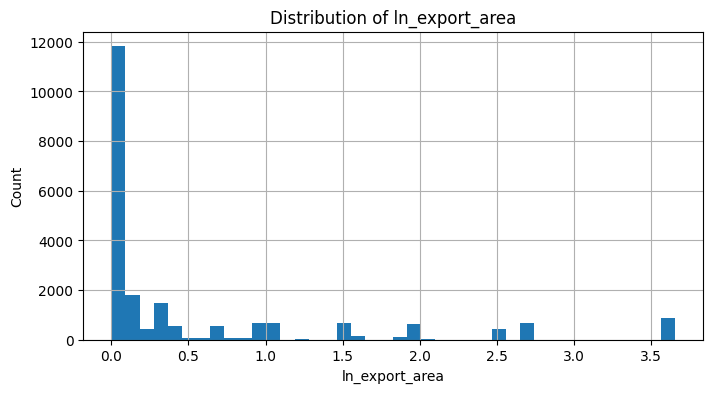

,outcome_label,learner,y_mse,d_mse,d_resid_sd
26,Intergroup trust,Boosting,0.8457,0.0369,0.1920
29,Intergroup trust,Ensemble,0.8351,0.0440,0.2097
27,Intergroup trust,Forest,0.8256,0.0107,0.1037
24,Intergroup trust,Lasso,0.8575,0.2614,0.5113
28,Intergroup trust,Neural Net,0.8854,0.0249,0.1577
25,Intergroup trust,Tree,0.8821,0.0043,0.0658
20,Intragroup trust,Boosting,0.8278,0.0369,0.1921
23,Intragroup trust,Ensemble,0.8146,0.0438,0.2092
21,Intragroup trust,Forest,0.8059,0.0106,0.1029
18,Intragroup trust,Lasso,0.8441,0.2617,0.5116


In [19]:
# Distribution of the treatment in the largest relevant sample.
plt.figure(figsize=(8, 4))
df[treatment].dropna().hist(bins=40)
plt.title("Distribution of ln_export_area")
plt.xlabel("ln_export_area")
plt.ylabel("Count")
plt.show()

# Nuisance prediction performance by outcome and learner.
if results_long.empty:
    raise ValueError(
        "results_long is empty. Run or load at least one outcome in Section 9 before diagnostics."
    )

nuisance_mse_table = results_long[
    ["outcome_label", "learner", "y_mse", "d_mse", "d_resid_sd"]
].sort_values(["outcome_label", "learner"])

display(nuisance_mse_table.round(4))

# Diagnostics should only use outcomes that have been run or loaded.
available_diagnostic_outcomes = [
    outcome for outcome in outcomes
    if outcome in set(best_by_outcome["outcome"])
]
missing_diagnostic_outcomes = [
    outcome for outcome in outcomes
    if outcome not in set(available_diagnostic_outcomes)
]

if missing_diagnostic_outcomes:
    print(
        "Skipping diagnostics for outcomes not yet present in best_by_outcome: "
        + ", ".join(missing_diagnostic_outcomes)
    )

if not available_diagnostic_outcomes:
    raise ValueError(
        "No outcomes are available for diagnostics. Run Section 10 after loading/running outcome results."
    )

This cell plots residualized treatment variation for each available outcome's nuisance-selected learner.

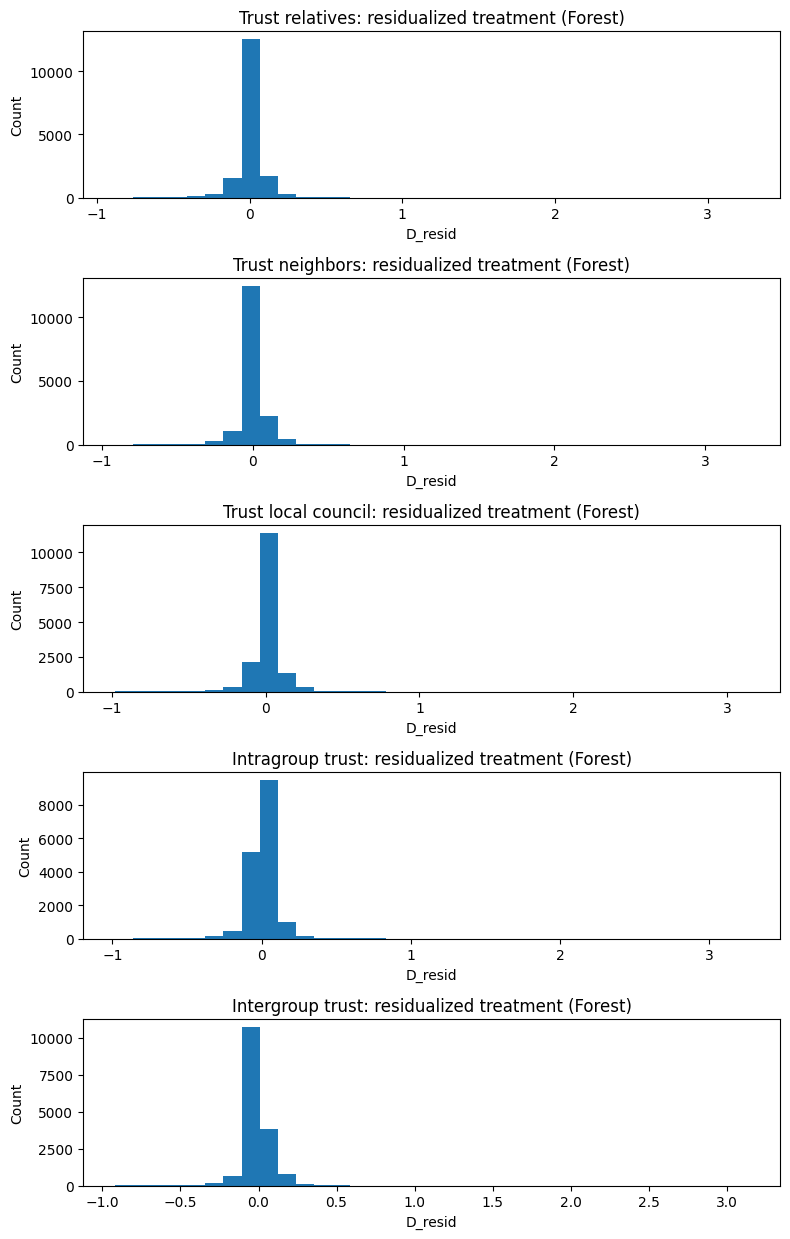

In [20]:
# Residualized treatment variation for each available outcome's best learner.
plot_outcomes = []
for outcome in available_diagnostic_outcomes:
    best_rows = best_by_outcome.loc[best_by_outcome["outcome"] == outcome, "learner"]
    if best_rows.empty:
        continue
    best_learner = best_rows.iloc[0]
    if (outcome, best_learner) in all_residuals:
        plot_outcomes.append((outcome, best_learner))
    else:
        print(f"Skipping {outcome}: residuals for best learner {best_learner} are not loaded.")

if not plot_outcomes:
    raise ValueError(
        "No residualized treatment diagnostics are available. "
        "Run or load the relevant outcome checkpoints before this cell."
    )

fig, axes = plt.subplots(
    len(plot_outcomes),
    1,
    figsize=(8, 2.5 * len(plot_outcomes)),
    sharex=False,
)
axes = np.atleast_1d(axes)

for ax, (outcome, best_learner) in zip(axes, plot_outcomes):
    d_resid = all_residuals[(outcome, best_learner)]["d_resid"]
    ax.hist(d_resid, bins=35)
    ax.set_title(f"{outcome_labels[outcome]}: residualized treatment ({best_learner})")
    ax.set_xlabel("D_resid")
    ax.set_ylabel("Count")

plt.tight_layout()
plt.show()

This cell plots split-specific coefficient distributions to show sensitivity to random fold assignment.

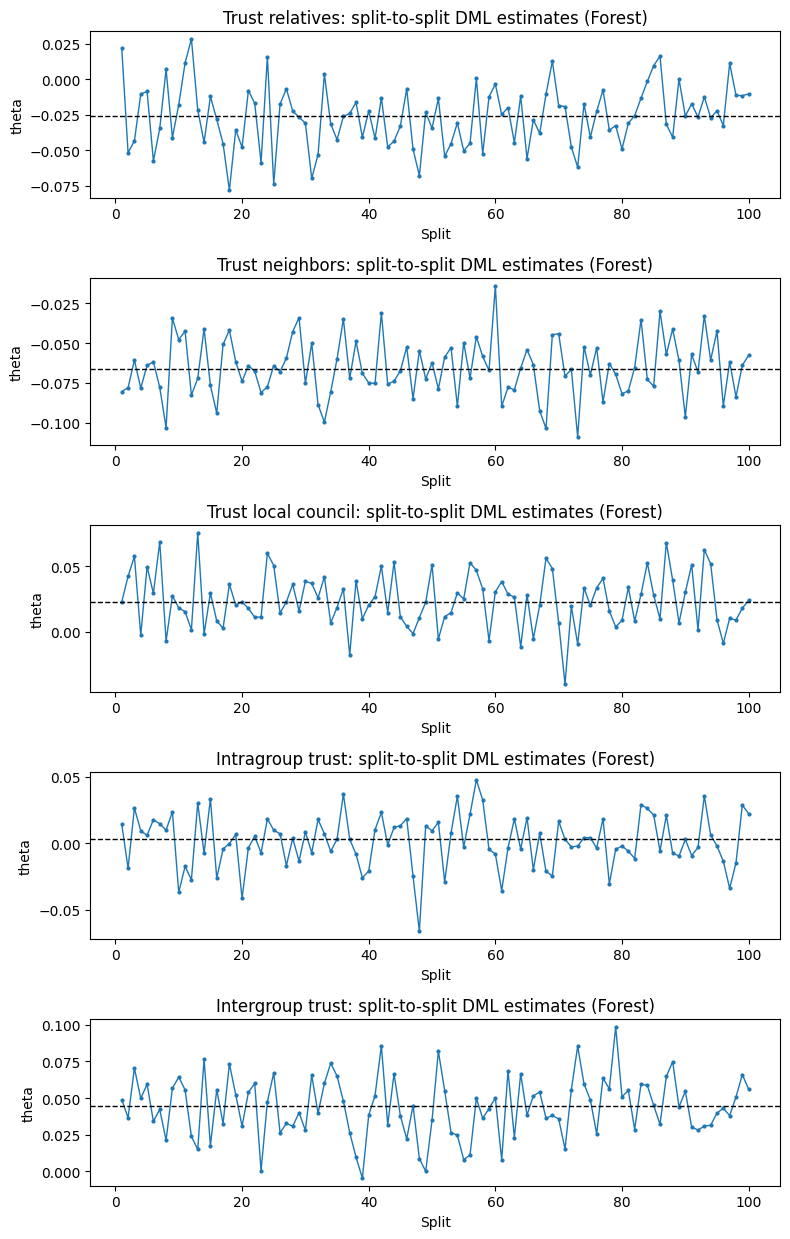

In [21]:
# Split-to-split variation in treatment-effect estimates for each available outcome's best learner.
plot_outcomes = []
for outcome in available_diagnostic_outcomes:
    best_rows = best_by_outcome.loc[best_by_outcome["outcome"] == outcome, "learner"]
    if best_rows.empty:
        continue
    best_learner = best_rows.iloc[0]
    if (outcome, best_learner) in all_split_tables:
        plot_outcomes.append((outcome, best_learner))
    else:
        print(f"Skipping {outcome}: split table for best learner {best_learner} is not loaded.")

if not plot_outcomes:
    raise ValueError(
        "No split-to-split diagnostics are available. "
        "Run or load the relevant outcome checkpoints before this cell."
    )

fig, axes = plt.subplots(
    len(plot_outcomes),
    1,
    figsize=(8, 2.5 * len(plot_outcomes)),
    sharex=False,
)
axes = np.atleast_1d(axes)

for ax, (outcome, best_learner) in zip(axes, plot_outcomes):
    split_table = all_split_tables[(outcome, best_learner)]
    ax.plot(split_table["split"], split_table["theta"], marker="o", linewidth=1, markersize=2)
    ax.axhline(split_table["theta"].median(), color="black", linestyle="--", linewidth=1)
    ax.set_title(f"{outcome_labels[outcome]}: split-to-split DML estimates ({best_learner})")
    ax.set_xlabel("Split")
    ax.set_ylabel("theta")

plt.tight_layout()
plt.show()

This cell compares treatment estimates across all learner families and visualizes learner sensitivity by outcome.

learner,Boosting,Ensemble,Forest,Lasso,Neural Net,Tree
outcome_label,,,,,,
Intergroup trust,0.027,-0.107,0.044,-0.117,-0.159,0.281
Intragroup trust,-0.104,-0.199,0.003,-0.195,-0.181,0.141
Trust local council,-0.119,-0.136,0.023,-0.121,-0.128,0.095
Trust neighbors,-0.107,-0.216,-0.066,-0.203,-0.213,0.053
Trust relatives,-0.082,-0.185,-0.026,-0.184,-0.177,-0.060


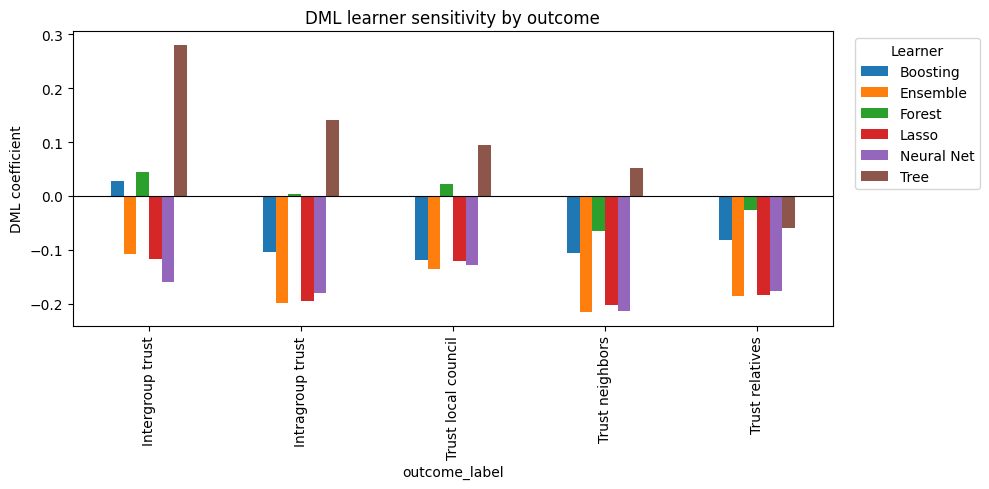

In [22]:
# Learner sensitivity: compare DML coefficients across all learners for available outcomes.
learner_sensitivity = results_long.pivot_table(
    index="outcome_label",
    columns="learner",
    values="theta",
    aggfunc="first",
)

if learner_sensitivity.empty:
    raise ValueError("No learner sensitivity table is available because results_long is empty.")

display(learner_sensitivity.round(3))

ax = learner_sensitivity.plot(kind="bar", figsize=(10, 5))
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("DML learner sensitivity by outcome")
ax.set_ylabel("DML coefficient")
ax.legend(title="Learner", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

## 14. Ethnicity-cluster cross-fitting

Random individual folds can place respondents from the same `murdock_name` group in both training and held-out samples. This robustness design holds out entire ethnicities, creating a stricter out-of-group prediction exercise while leaving the estimand, controls, learners, final stage, and two-way clustered inference unchanged.

This helper assigns whole ethnicity groups to folds so no `murdock_name` appears in both the training and held-out samples.

In [23]:
def iter_cluster_kfold_indices(clusters, n_folds=2, random_state=1211):
    """Yield K-fold train/test indices that keep clusters intact across folds."""
    clusters = pd.Series(clusters).astype(str).reset_index(drop=True)
    unique_clusters = clusters.unique()

    if n_folds < 2:
        raise ValueError("n_folds must be at least 2.")
    if n_folds > len(unique_clusters):
        raise ValueError(
            f"n_folds={n_folds} exceeds the number of unique clusters={len(unique_clusters)}."
        )

    rng = np.random.default_rng(random_state)
    shuffled_clusters = rng.permutation(unique_clusters)
    cluster_folds = np.array_split(shuffled_clusters, n_folds)

    for held_out_clusters in cluster_folds:
        held_out = set(held_out_clusters)
        test_mask = clusters.isin(held_out).to_numpy()
        train_idx = np.flatnonzero(~test_mask)
        test_idx = np.flatnonzero(test_mask)

        train_clusters = set(clusters.iloc[train_idx])
        test_clusters = set(clusters.iloc[test_idx])
        assert train_clusters.isdisjoint(test_clusters)
        assert len(train_idx) > 0 and len(test_idx) > 0

        yield train_idx, test_idx

This estimator repeats the partially linear DML procedure using ethnicity-cluster folds and returns the same summaries and diagnostics as the main estimator.

In [24]:
def dml_plr_repeated_cluster_crossfit(
    Y,
    D,
    X,
    clusters,
    learner_name,
    split_cluster="murdock_name",
    n_splits=100,
    n_folds=2,
    random_seed=1211,
):
    """Repeated DML with cross-fitting folds held out by cluster."""
    Y = np.asarray(Y, dtype=float)
    D = np.asarray(D, dtype=float)
    X = X.copy()
    learner_factories = make_learner_factories()

    if split_cluster not in clusters.columns:
        raise ValueError(f"split_cluster={split_cluster!r} is not in clusters columns {list(clusters.columns)}")

    split_results = []
    residual_store = {}

    for split in range(n_splits):
        split_seed = random_seed + split

        y_hat = np.zeros_like(Y, dtype=float)
        d_hat = np.zeros_like(D, dtype=float)

        for fold, (train_idx, test_idx) in enumerate(
            iter_cluster_kfold_indices(
                clusters[split_cluster],
                n_folds=n_folds,
                random_state=split_seed,
            ),
            start=1,
        ):
            learner_y = learner_factories[learner_name](split_seed + fold)
            learner_d = learner_factories[learner_name](split_seed + 10_000 + fold)

            X_train = X.iloc[train_idx]
            X_test = X.iloc[test_idx]

            # First nuisance function: E[Y | X]. D is deliberately excluded.
            learner_y.fit(X_train, Y[train_idx])
            y_hat[test_idx] = learner_y.predict(X_test)

            # Second nuisance function: E[D | X]. Y is deliberately excluded.
            learner_d.fit(X_train, D[train_idx])
            d_hat[test_idx] = learner_d.predict(X_test)

            # Keep GPU memory tidy across many repeated folds in Colab.
            del learner_y, learner_d
            cp.get_default_memory_pool().free_all_blocks()
            if torch.cuda.is_available():
                torch.cuda.empty_cache()

        y_resid = Y - y_hat
        d_resid = D - d_hat
        final = two_way_cluster_se_no_intercept(y_resid, d_resid, clusters)

        split_results.append(
            {
                "split": split + 1,
                "theta": final["theta"],
                "se": final["se"],
                "t": final["t"],
                "p": final["p"],
                "y_mse": mse(Y, y_hat),
                "d_mse": mse(D, d_hat),
                "d_resid_sd": np.std(d_resid, ddof=1),
                "raw_variance": final["raw_variance"],
            }
        )

        residual_store[split + 1] = {
            "y_hat": y_hat,
            "d_hat": d_hat,
            "y_resid": y_resid,
            "d_resid": d_resid,
        }

    split_table = pd.DataFrame(split_results)
    median_theta = split_table["theta"].median()
    median_split = int((split_table["theta"] - median_theta).abs().idxmin()) + 1

    within_var = np.nanmedian(split_table["se"] ** 2)
    between_var = np.nanvar(split_table["theta"], ddof=1) if n_splits > 1 else 0.0
    split_adjusted_se = float(np.sqrt(within_var + between_var))
    dof = max(min(clusters["murdock_name"].nunique(), clusters["district"].nunique()) - 1, 1)
    t_stat = median_theta / split_adjusted_se if split_adjusted_se > 0 else np.nan
    p_value = 2 * stats.t.sf(np.abs(t_stat), df=dof) if split_adjusted_se > 0 else np.nan

    summary = {
        "learner": learner_name,
        "n_splits": n_splits,
        "n_folds": n_folds,
        "split_cluster": split_cluster,
        "theta": median_theta,
        "se": split_adjusted_se,
        "t": t_stat,
        "p": p_value,
        "median_split": median_split,
        "median_split_se": split_table.loc[split_table["split"] == median_split, "se"].iloc[0],
        "split_sd": float(split_table["theta"].std(ddof=1)) if n_splits > 1 else 0.0,
        "y_mse": float(split_table["y_mse"].median()),
        "d_mse": float(split_table["d_mse"].median()),
        "d_resid_sd": float(split_table["d_resid_sd"].median()),
    }

    return {
        "summary": summary,
        "splits": split_table,
        "residuals": residual_store[median_split],
    }

### Cluster-fold configuration and checkpoints

This cell defines cluster-fold run settings, separate checkpoint storage, and load/save helpers for the robustness results.

In [25]:
import pickle

CLUSTER_N_SPLITS = 100
CLUSTER_N_FOLDS = 2
CLUSTER_RANDOM_SEED = 1211
CLUSTER_SPLIT_VARIABLE = "murdock_name"

# For a quick smoke test, temporarily set:
# CLUSTER_N_SPLITS = 2

CLUSTER_CHECKPOINT_DIR = PROJECT_ROOT / "dml_checkpoints_cluster_murdock"
CLUSTER_CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

cluster_summaries = []
cluster_split_tables = {}
cluster_residuals = {}
cluster_results_long = pd.DataFrame()


def cluster_checkpoint_path(outcome):
    """Path for one outcome's ethnicity-cluster cross-fit checkpoint."""
    return CLUSTER_CHECKPOINT_DIR / f"dml_cluster_{outcome}.pkl"


def refresh_cluster_results_long():
    """Rebuild the cluster-robustness long-form result table."""
    global cluster_results_long
    cluster_results_long = pd.DataFrame(cluster_summaries)
    return cluster_results_long


def remove_cluster_outcome_from_memory(outcome):
    """Remove one outcome from in-memory cluster-robustness containers."""
    global cluster_summaries, cluster_split_tables, cluster_residuals

    cluster_summaries = [row for row in cluster_summaries if row["outcome"] != outcome]
    for key in list(cluster_split_tables.keys()):
        if key[0] == outcome:
            del cluster_split_tables[key]
    for key in list(cluster_residuals.keys()):
        if key[0] == outcome:
            del cluster_residuals[key]


def save_cluster_outcome_checkpoint(outcome):
    """Persist one completed ethnicity-cluster robustness run to Google Drive."""
    path = cluster_checkpoint_path(outcome)
    payload = {
        "outcome": outcome,
        "split_cluster": CLUSTER_SPLIT_VARIABLE,
        "n_splits": CLUSTER_N_SPLITS,
        "n_folds": CLUSTER_N_FOLDS,
        "random_seed": CLUSTER_RANDOM_SEED,
        "summaries": [row for row in cluster_summaries if row["outcome"] == outcome],
        "split_tables": {
            key: value for key, value in cluster_split_tables.items()
            if key[0] == outcome
        },
        "residuals": {
            key: value for key, value in cluster_residuals.items()
            if key[0] == outcome
        },
    }

    with open(path, "wb") as f:
        pickle.dump(payload, f)

    print(f"Saved cluster checkpoint: {path}")


def load_cluster_outcome_checkpoint(outcome):
    """Load one ethnicity-cluster checkpoint from Google Drive if it exists."""
    path = cluster_checkpoint_path(outcome)
    if not path.exists():
        return False

    with open(path, "rb") as f:
        payload = pickle.load(f)

    remove_cluster_outcome_from_memory(outcome)
    cluster_summaries.extend(payload["summaries"])
    cluster_split_tables.update(payload["split_tables"])
    cluster_residuals.update(payload["residuals"])
    refresh_cluster_results_long()

    saved_config = (
        payload.get("split_cluster"),
        payload.get("n_splits"),
        payload.get("n_folds"),
        payload.get("random_seed"),
    )
    current_config = (
        CLUSTER_SPLIT_VARIABLE,
        CLUSTER_N_SPLITS,
        CLUSTER_N_FOLDS,
        CLUSTER_RANDOM_SEED,
    )

    if saved_config != current_config:
        print(
            f"Loaded cluster checkpoint with run settings {saved_config}; "
            f"current settings are {current_config}. Use force=True to recompute."
        )
    else:
        print(f"Loaded cluster checkpoint: {path}")
    return True

This controller prepares one outcome, runs every learner with ethnicity-cluster folds, and updates the cluster-robustness result stores.

In [26]:
def run_cluster_dml_for_outcome(outcome, split_cluster=CLUSTER_SPLIT_VARIABLE, force=False):
    """Run all learners for one outcome using ethnicity-cluster cross-fitting."""
    global cluster_summaries, cluster_split_tables, cluster_residuals, cluster_results_long

    if split_cluster != CLUSTER_SPLIT_VARIABLE:
        raise ValueError(
            f"This checkpoint setup is configured for {CLUSTER_SPLIT_VARIABLE!r}; "
            f"got split_cluster={split_cluster!r}."
        )

    if not force and load_cluster_outcome_checkpoint(outcome):
        return cluster_results_long.loc[cluster_results_long["outcome"] == outcome].sort_values("learner")

    remove_cluster_outcome_from_memory(outcome)

    prepared = prepare_table3_sample(df, outcome)
    Y = prepared["Y"]
    D = prepared["D"]
    X = prepared["X"]
    clusters = prepared["clusters"]

    print(
        f"\nCluster cross-fit outcome: {outcome} | "
        f"N={prepared['n']:,} | X columns={X.shape[1]:,} | "
        f"split cluster={split_cluster} ({clusters[split_cluster].nunique()} groups)"
    )

    for learner_name in make_learners().keys():
        print(f"  Running {learner_name} with {split_cluster}-cluster folds...")
        result = dml_plr_repeated_cluster_crossfit(
            Y=Y,
            D=D,
            X=X,
            clusters=clusters,
            learner_name=learner_name,
            split_cluster=split_cluster,
            n_splits=CLUSTER_N_SPLITS,
            n_folds=CLUSTER_N_FOLDS,
            random_seed=CLUSTER_RANDOM_SEED,
        )

        summary = {
            "outcome": outcome,
            "outcome_label": outcome_labels[outcome],
            "crossfit_design": "ethnicity_cluster",
            "learner": learner_name,
            "N": prepared["n"],
            "ethnicity_clusters": prepared["n_ethnicity_clusters"],
            "district_clusters": prepared["n_district_clusters"],
            **result["summary"],
        }

        cluster_summaries.append(summary)
        cluster_split_tables[(outcome, learner_name)] = result["splits"]
        cluster_residuals[(outcome, learner_name)] = result["residuals"]

    refresh_cluster_results_long()
    save_cluster_outcome_checkpoint(outcome)
    return cluster_results_long.loc[cluster_results_long["outcome"] == outcome].sort_values("learner")

### Outcome-specific cluster-fold estimates

This cell runs or loads the cluster-fold specification for trust in relatives.

In [27]:
run_cluster_dml_for_outcome("trust_relatives")

,outcome,outcome_label,crossfit_design,learner,N,ethnicity_clusters,district_clusters,n_splits,n_folds,split_cluster,theta,se,t,p,median_split,median_split_se,split_sd,y_mse,d_mse,d_resid_sd
2,trust_relatives,Trust relatives,ethnicity_cluster,Boosting,16709,147,1187,100,2,murdock_name,-0.106984,0.058147,-1.839895,0.067814,93,0.032957,0.038998,0.850536,0.997816,0.953021
5,trust_relatives,Trust relatives,ethnicity_cluster,Ensemble,16709,147,1187,100,2,murdock_name,-0.133414,0.057952,-2.302160,0.022740,3,0.066834,0.032745,0.844165,0.885041,0.919218
3,trust_relatives,Trust relatives,ethnicity_cluster,Forest,16709,147,1187,100,2,murdock_name,-0.112114,0.057674,-1.943934,0.053826,46,0.065670,0.029676,0.837325,0.887828,0.908281
0,trust_relatives,Trust relatives,ethnicity_cluster,Lasso,16709,147,1187,100,2,murdock_name,-0.143517,0.062085,-2.311625,0.022197,36,0.058962,0.035809,0.860009,1.195943,1.077282
4,trust_relatives,Trust relatives,ethnicity_cluster,Neural Net,16709,147,1187,100,2,murdock_name,-0.118022,0.084536,-1.396104,0.164802,72,0.104172,0.056051,1.016622,1.057091,1.005639
1,trust_relatives,Trust relatives,ethnicity_cluster,Tree,16709,147,1187,100,2,murdock_name,-0.047598,0.101004,-0.471251,0.638165,40,0.065559,0.085362,0.939610,1.237657,1.062123


This cell runs or loads the cluster-fold specification for trust in neighbors.

In [28]:
run_cluster_dml_for_outcome("trust_neighbors")

,outcome,outcome_label,crossfit_design,learner,N,ethnicity_clusters,district_clusters,n_splits,n_folds,split_cluster,theta,se,t,p,median_split,median_split_se,split_sd,y_mse,d_mse,d_resid_sd
8,trust_neighbors,Trust neighbors,ethnicity_cluster,Boosting,16679,147,1187,100,2,murdock_name,-0.132263,0.047861,-2.763480,0.006456,98,0.038029,0.035199,0.899025,0.996026,0.951905
11,trust_neighbors,Trust neighbors,ethnicity_cluster,Ensemble,16679,147,1187,100,2,murdock_name,-0.162870,0.043995,-3.702025,0.000302,29,0.025783,0.030623,0.895407,0.886326,0.925488
9,trust_neighbors,Trust neighbors,ethnicity_cluster,Forest,16679,147,1187,100,2,murdock_name,-0.139448,0.048693,-2.863823,0.004803,11,0.026578,0.030186,0.894077,0.887517,0.904329
6,trust_neighbors,Trust neighbors,ethnicity_cluster,Lasso,16679,147,1187,100,2,murdock_name,-0.171450,0.055155,-3.108526,0.002261,33,0.049676,0.038908,0.915825,1.198185,1.077834
10,trust_neighbors,Trust neighbors,ethnicity_cluster,Neural Net,16679,147,1187,100,2,murdock_name,-0.156446,0.065453,-2.390200,0.018115,88,0.045593,0.046953,1.050989,1.041879,1.004308
7,trust_neighbors,Trust neighbors,ethnicity_cluster,Tree,16679,147,1187,100,2,murdock_name,-0.098834,0.080970,-1.220622,0.224197,58,0.036090,0.063298,1.016025,1.254010,1.072964


This cell runs or loads the cluster-fold specification for trust in the local council.

In [29]:
run_cluster_dml_for_outcome("trust_local_council")

,outcome,outcome_label,crossfit_design,learner,N,ethnicity_clusters,district_clusters,n_splits,n_folds,split_cluster,theta,se,t,p,median_split,median_split_se,split_sd,y_mse,d_mse,d_resid_sd
14,trust_local_council,Trust local council,ethnicity_cluster,Boosting,15905,146,1194,100,2,murdock_name,-0.083579,0.031194,-2.679298,0.008231,5,0.012410,0.024383,1.015422,0.984349,0.952475
17,trust_local_council,Trust local council,ethnicity_cluster,Ensemble,15905,146,1194,100,2,murdock_name,-0.090712,0.035489,-2.556047,0.011616,20,0.029809,0.028540,1.004641,0.894139,0.920704
15,trust_local_council,Trust local council,ethnicity_cluster,Forest,15905,146,1194,100,2,murdock_name,-0.072590,0.035631,-2.037301,0.043439,90,0.020527,0.026170,1.023043,0.894955,0.906351
12,trust_local_council,Trust local council,ethnicity_cluster,Lasso,15905,146,1194,100,2,murdock_name,-0.107454,0.035123,-3.059333,0.002643,64,0.015733,0.026030,1.009446,1.181605,1.069993
16,trust_local_council,Trust local council,ethnicity_cluster,Neural Net,15905,146,1194,100,2,murdock_name,-0.070342,0.064193,-1.095782,0.274991,33,0.024839,0.050465,1.146463,1.066084,1.002011
13,trust_local_council,Trust local council,ethnicity_cluster,Tree,15905,146,1194,100,2,murdock_name,-0.093084,0.061258,-1.519541,0.130804,57,0.060807,0.043672,1.139064,1.218448,1.044095


This cell runs or loads the cluster-fold specification for intragroup trust.

In [30]:
run_cluster_dml_for_outcome("intra_group_trust")

,outcome,outcome_label,crossfit_design,learner,N,ethnicity_clusters,district_clusters,n_splits,n_folds,split_cluster,theta,se,t,p,median_split,median_split_se,split_sd,y_mse,d_mse,d_resid_sd
20,intra_group_trust,Intragroup trust,ethnicity_cluster,Boosting,16636,147,1186,100,2,murdock_name,-0.125955,0.048014,-2.623317,0.009633,26,0.025578,0.037073,0.895141,0.996414,0.951836
23,intra_group_trust,Intragroup trust,ethnicity_cluster,Ensemble,16636,147,1186,100,2,murdock_name,-0.151116,0.044347,-3.407561,0.000847,44,0.048754,0.031357,0.889539,0.889412,0.924082
21,intra_group_trust,Intragroup trust,ethnicity_cluster,Forest,16636,147,1186,100,2,murdock_name,-0.125178,0.047964,-2.609858,0.010002,18,0.034435,0.030474,0.886632,0.891065,0.906171
18,intra_group_trust,Intragroup trust,ethnicity_cluster,Lasso,16636,147,1186,100,2,murdock_name,-0.176173,0.052196,-3.375229,0.000945,22,0.037113,0.038613,0.917290,1.201777,1.078972
22,intra_group_trust,Intragroup trust,ethnicity_cluster,Neural Net,16636,147,1186,100,2,murdock_name,-0.128641,0.066625,-1.930830,0.055442,12,0.044989,0.051255,1.015331,1.049302,1.004705
19,intra_group_trust,Intragroup trust,ethnicity_cluster,Tree,16636,147,1186,100,2,murdock_name,-0.103806,0.094463,-1.098912,0.273615,65,0.029208,0.077916,1.024462,1.244047,1.063931


This cell runs or loads the cluster-fold specification for intergroup trust.

In [31]:
run_cluster_dml_for_outcome("inter_group_trust")

,outcome,outcome_label,crossfit_design,learner,N,ethnicity_clusters,district_clusters,n_splits,n_folds,split_cluster,theta,se,t,p,median_split,median_split_se,split_sd,y_mse,d_mse,d_resid_sd
26,inter_group_trust,Intergroup trust,ethnicity_cluster,Boosting,16473,147,1184,100,2,murdock_name,-0.062504,0.040089,-1.559141,0.121128,63,0.024365,0.030594,0.887682,0.995856,0.956094
29,inter_group_trust,Intergroup trust,ethnicity_cluster,Ensemble,16473,147,1184,100,2,murdock_name,-0.089313,0.035745,-2.498642,0.013575,52,0.025093,0.026055,0.889360,0.886079,0.922519
27,inter_group_trust,Intergroup trust,ethnicity_cluster,Forest,16473,147,1184,100,2,murdock_name,-0.069858,0.039179,-1.783041,0.076657,11,0.032011,0.024353,0.887893,0.895183,0.907838
24,inter_group_trust,Intergroup trust,ethnicity_cluster,Lasso,16473,147,1184,100,2,murdock_name,-0.102181,0.040876,-2.499785,0.013533,25,0.036673,0.029799,0.902740,1.201744,1.078028
28,inter_group_trust,Intergroup trust,ethnicity_cluster,Neural Net,16473,147,1184,100,2,murdock_name,-0.099841,0.057114,-1.748111,0.082547,7,0.054806,0.044136,1.017816,1.045569,1.001161
25,inter_group_trust,Intergroup trust,ethnicity_cluster,Tree,16473,147,1184,100,2,murdock_name,-0.053274,0.071194,-0.748295,0.455486,12,0.034090,0.056288,0.991097,1.244114,1.065641


This cell assembles the available ethnicity-cluster summaries into a long-form table.

In [32]:
cluster_results_long = pd.DataFrame(cluster_summaries)
cluster_results_long.sort_values(["outcome", "learner"])

,outcome,outcome_label,crossfit_design,learner,N,ethnicity_clusters,district_clusters,n_splits,n_folds,split_cluster,theta,se,t,p,median_split,median_split_se,split_sd,y_mse,d_mse,d_resid_sd
26,inter_group_trust,Intergroup trust,ethnicity_cluster,Boosting,16473,147,1184,100,2,murdock_name,-0.062504,0.040089,-1.559141,0.121128,63,0.024365,0.030594,0.887682,0.995856,0.956094
29,inter_group_trust,Intergroup trust,ethnicity_cluster,Ensemble,16473,147,1184,100,2,murdock_name,-0.089313,0.035745,-2.498642,0.013575,52,0.025093,0.026055,0.889360,0.886079,0.922519
27,inter_group_trust,Intergroup trust,ethnicity_cluster,Forest,16473,147,1184,100,2,murdock_name,-0.069858,0.039179,-1.783041,0.076657,11,0.032011,0.024353,0.887893,0.895183,0.907838
24,inter_group_trust,Intergroup trust,ethnicity_cluster,Lasso,16473,147,1184,100,2,murdock_name,-0.102181,0.040876,-2.499785,0.013533,25,0.036673,0.029799,0.902740,1.201744,1.078028
28,inter_group_trust,Intergroup trust,ethnicity_cluster,Neural Net,16473,147,1184,100,2,murdock_name,-0.099841,0.057114,-1.748111,0.082547,7,0.054806,0.044136,1.017816,1.045569,1.001161
25,inter_group_trust,Intergroup trust,ethnicity_cluster,Tree,16473,147,1184,100,2,murdock_name,-0.053274,0.071194,-0.748295,0.455486,12,0.034090,0.056288,0.991097,1.244114,1.065641
20,intra_group_trust,Intragroup trust,ethnicity_cluster,Boosting,16636,147,1186,100,2,murdock_name,-0.125955,0.048014,-2.623317,0.009633,26,0.025578,0.037073,0.895141,0.996414,0.951836
23,intra_group_trust,Intragroup trust,ethnicity_cluster,Ensemble,16636,147,1186,100,2,murdock_name,-0.151116,0.044347,-3.407561,0.000847,44,0.048754,0.031357,0.889539,0.889412,0.924082
21,intra_group_trust,Intragroup trust,ethnicity_cluster,Forest,16636,147,1186,100,2,murdock_name,-0.125178,0.047964,-2.609858,0.010002,18,0.034435,0.030474,0.886632,0.891065,0.906171
18,intra_group_trust,Intragroup trust,ethnicity_cluster,Lasso,16636,147,1186,100,2,murdock_name,-0.176173,0.052196,-3.375229,0.000945,22,0.037113,0.038613,0.917290,1.201777,1.078972


### Main and cluster-fold comparison

This cell applies the same nuisance-performance selection rule to the cluster-fold results and compares selected main and robustness estimates.

In [33]:
if cluster_results_long.empty:
    raise ValueError(
        "cluster_results_long is empty. Run or load at least one cluster robustness outcome first."
    )

cluster_results_ranked, cluster_best_by_outcome = choose_best_learners(cluster_results_long)

# Recompute the main best table if needed so this section can be rerun cleanly.
if "best_by_outcome" not in globals() or best_by_outcome.empty:
    if results_long.empty:
        raise ValueError(
            "Main results_long is empty. Run or load the main Section 9 outcomes before comparison."
        )
    results_ranked, best_by_outcome = choose_best_learners(results_long)

main_best = best_by_outcome[
    [
        "outcome",
        "learner",
        "theta",
        "se",
        "N",
        "ethnicity_clusters",
        "district_clusters",
    ]
].rename(
    columns={
        "learner": "Main DML best learner",
        "theta": "Main DML best estimate",
        "se": "Main DML best SE",
    }
)

cluster_best = cluster_best_by_outcome[
    [
        "outcome",
        "learner",
        "theta",
        "se",
        "N",
        "ethnicity_clusters",
        "district_clusters",
    ]
].rename(
    columns={
        "learner": "Cluster DML best learner",
        "theta": "Cluster DML best estimate",
        "se": "Cluster DML best SE",
    }
)

cluster_comparison = main_best.merge(
    cluster_best,
    on=["outcome", "N", "ethnicity_clusters", "district_clusters"],
    how="outer",
)
cluster_comparison.insert(0, "Outcome", cluster_comparison["outcome"].map(outcome_labels))
cluster_comparison.insert(
    1,
    "Original Table 3 OLS coefficient",
    cluster_comparison["outcome"].map(original_ols),
)

comparison_columns = [
    "Outcome",
    "Original Table 3 OLS coefficient",
    "Main DML best learner",
    "Main DML best estimate",
    "Main DML best SE",
    "Cluster DML best learner",
    "Cluster DML best estimate",
    "Cluster DML best SE",
    "N",
    "ethnicity_clusters",
    "district_clusters",
]
cluster_comparison = cluster_comparison[comparison_columns]

formatted_cluster_comparison = cluster_comparison.copy()
for col in [
    "Original Table 3 OLS coefficient",
    "Main DML best estimate",
    "Main DML best SE",
    "Cluster DML best estimate",
    "Cluster DML best SE",
]:
    formatted_cluster_comparison[col] = formatted_cluster_comparison[col].round(3)

display(formatted_cluster_comparison)

,Outcome,Original Table 3 OLS coefficient,Main DML best learner,Main DML best estimate,Main DML best SE,Cluster DML best learner,Cluster DML best estimate,Cluster DML best SE,N,ethnicity_clusters,district_clusters
0,Intergroup trust,-0.115,Forest,0.044,0.088,Boosting,-0.063,0.040,16473,147,1184
1,Intragroup trust,-0.188,Forest,0.003,0.090,Forest,-0.125,0.048,16636,147,1186
2,Trust local council,-0.129,Forest,0.023,0.073,Ensemble,-0.091,0.035,15905,146,1194
3,Trust neighbors,-0.202,Forest,-0.066,0.086,Forest,-0.139,0.049,16679,147,1187
4,Trust relatives,-0.178,Forest,-0.026,0.073,Forest,-0.112,0.058,16709,147,1187


This cell compares nuisance losses and residualized treatment variation between random individual folds and ethnicity-cluster folds.

In [34]:
# Cluster-cross-fitting nuisance prediction table.
cluster_nuisance_mse_table = cluster_results_long[
    ["outcome_label", "learner", "y_mse", "d_mse", "d_resid_sd"]
].sort_values(["outcome_label", "learner"])

display(cluster_nuisance_mse_table.round(4))

# Compare residualized treatment variation between the main and cluster-cross-fit runs.
main_d_resid = results_long[
    ["outcome", "outcome_label", "learner", "d_mse", "d_resid_sd"]
].rename(columns={"d_mse": "main_d_mse", "d_resid_sd": "main_d_resid_sd"})
cluster_d_resid = cluster_results_long[
    ["outcome", "learner", "d_mse", "d_resid_sd"]
].rename(columns={"d_mse": "cluster_d_mse", "d_resid_sd": "cluster_d_resid_sd"})

d_resid_comparison = main_d_resid.merge(
    cluster_d_resid,
    on=["outcome", "learner"],
    how="inner",
)

display(
    d_resid_comparison.sort_values(["outcome_label", "learner"]).round(4)
)

,outcome_label,learner,y_mse,d_mse,d_resid_sd
26,Intergroup trust,Boosting,0.8877,0.9959,0.9561
29,Intergroup trust,Ensemble,0.8894,0.8861,0.9225
27,Intergroup trust,Forest,0.8879,0.8952,0.9078
24,Intergroup trust,Lasso,0.9027,1.2017,1.0780
28,Intergroup trust,Neural Net,1.0178,1.0456,1.0012
25,Intergroup trust,Tree,0.9911,1.2441,1.0656
20,Intragroup trust,Boosting,0.8951,0.9964,0.9518
23,Intragroup trust,Ensemble,0.8895,0.8894,0.9241
21,Intragroup trust,Forest,0.8866,0.8911,0.9062
18,Intragroup trust,Lasso,0.9173,1.2018,1.0790


,outcome,outcome_label,learner,main_d_mse,main_d_resid_sd,cluster_d_mse,cluster_d_resid_sd
26,inter_group_trust,Intergroup trust,Boosting,0.0369,0.1920,0.9959,0.9561
29,inter_group_trust,Intergroup trust,Ensemble,0.0440,0.2097,0.8861,0.9225
27,inter_group_trust,Intergroup trust,Forest,0.0107,0.1037,0.8952,0.9078
24,inter_group_trust,Intergroup trust,Lasso,0.2614,0.5113,1.2017,1.0780
28,inter_group_trust,Intergroup trust,Neural Net,0.0249,0.1577,1.0456,1.0012
25,inter_group_trust,Intergroup trust,Tree,0.0043,0.0658,1.2441,1.0656
20,intra_group_trust,Intragroup trust,Boosting,0.0369,0.1921,0.9964,0.9518
23,intra_group_trust,Intragroup trust,Ensemble,0.0438,0.2092,0.8894,0.9241
21,intra_group_trust,Intragroup trust,Forest,0.0106,0.1029,0.8911,0.9062
18,intra_group_trust,Intragroup trust,Lasso,0.2617,0.5116,1.2018,1.0790


This cell reports and plots learner-specific estimates under ethnicity-cluster cross-fitting.

learner,Boosting,Ensemble,Forest,Lasso,Neural Net,Tree
outcome_label,,,,,,
Intergroup trust,-0.063,-0.089,-0.070,-0.102,-0.100,-0.053
Intragroup trust,-0.126,-0.151,-0.125,-0.176,-0.129,-0.104
Trust local council,-0.084,-0.091,-0.073,-0.107,-0.070,-0.093
Trust neighbors,-0.132,-0.163,-0.139,-0.171,-0.156,-0.099
Trust relatives,-0.107,-0.133,-0.112,-0.144,-0.118,-0.048


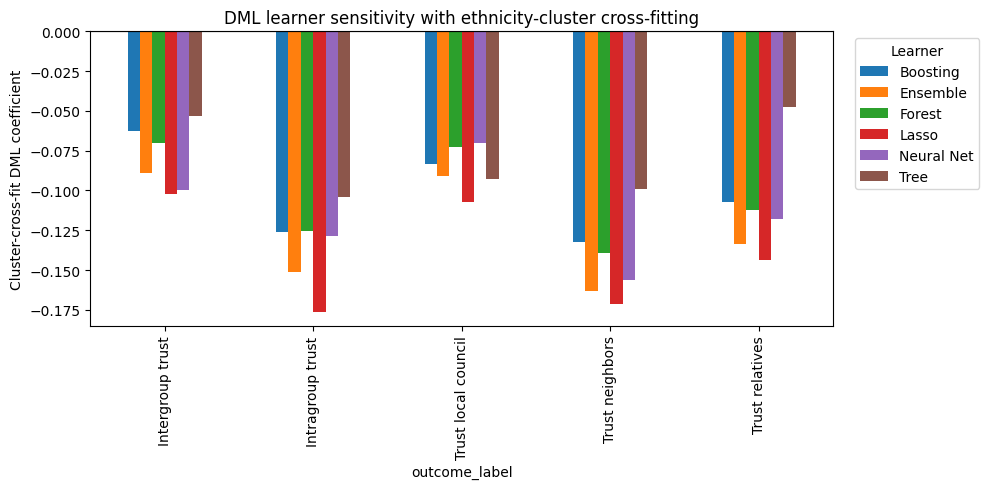

In [35]:
# Learner sensitivity under ethnicity-cluster cross-fitting.
cluster_learner_sensitivity = cluster_results_long.pivot_table(
    index="outcome_label",
    columns="learner",
    values="theta",
    aggfunc="first",
)

if cluster_learner_sensitivity.empty:
    raise ValueError("No cluster learner sensitivity table is available because cluster_results_long is empty.")

display(cluster_learner_sensitivity.round(3))

ax = cluster_learner_sensitivity.plot(kind="bar", figsize=(10, 5))
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title("DML learner sensitivity with ethnicity-cluster cross-fitting")
ax.set_ylabel("Cluster-cross-fit DML coefficient")
ax.legend(title="Learner", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

### Reading the cluster-fold diagnostics

The comparison emphasizes changes in nuisance error, residualized treatment variation, split stability, and learner sensitivity. Weaker prediction is expected when whole ethnicities are held out; large changes in the treatment estimate indicate dependence on the original fold design.

## 15. Conservative-learner sensitivity analysis

This analysis combines more regularized tree, forest, linear, and neural-network learners with random two-fold and ethnicity-cluster five-fold cross-fitting. Results are stored separately from the main specifications.

This cell defines the conservative learner menu, the two sensitivity fold designs, and fold-generation and memory-management helpers.

In [36]:
TABLE3_SENSITIVITY_VERSION = "conservative_tree_forest_elasticnet_cluster5_v1"
TABLE3_SENSITIVITY_N_SPLITS = 100
TABLE3_SENSITIVITY_RANDOM_SEED = 1211

TABLE3_SENSITIVITY_CHECKPOINT_DIR = PROJECT_ROOT / "dml_table3_sensitivity_checkpoints"
TABLE3_SENSITIVITY_CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

TABLE3_SENSITIVITY_DESIGNS = {
    "random_folds_conservative": {
        "label": "Random folds, conservative learners",
        "cluster_folds": False,
        "split_cluster": None,
        "n_folds": 2,
        "n_splits": TABLE3_SENSITIVITY_N_SPLITS,
    },
    "ethnicity_cluster_5fold_conservative": {
        "label": "Ethnicity-cluster 5-folds, conservative learners",
        "cluster_folds": True,
        "split_cluster": "murdock_name",
        "n_folds": 5,
        "n_splits": TABLE3_SENSITIVITY_N_SPLITS,
    },
}


class SensitivityStandardizedElasticNetRegressor:
    """GPU Elastic Net with internal standardization; l1_ratio near zero is ridge-style."""
    def __init__(self, alpha=0.005, l1_ratio=0.5, max_iter=20_000, random_state=1211):
        self.alpha = alpha
        self.l1_ratio = l1_ratio
        self.max_iter = max_iter
        self.random_state = random_state

    def fit(self, X, y):
        X_np = as_float32_numpy(X)
        self.x_mean_ = X_np.mean(axis=0, keepdims=True)
        self.x_std_ = X_np.std(axis=0, keepdims=True)
        self.x_std_[self.x_std_ == 0] = 1.0
        X_gpu = cudf.DataFrame((X_np - self.x_mean_) / self.x_std_)
        y_gpu = cudf.Series(np.asarray(y, dtype=np.float32))
        self.model_ = CuElasticNet(
            alpha=self.alpha,
            l1_ratio=self.l1_ratio,
            max_iter=self.max_iter,
            fit_intercept=True,
        )
        self.model_.fit(X_gpu, y_gpu)
        return self

    def predict(self, X):
        X_np = as_float32_numpy(X)
        X_gpu = cudf.DataFrame((X_np - self.x_mean_) / self.x_std_)
        return to_numpy_1d(self.model_.predict(X_gpu))


def make_table3_sensitivity_learner_factories():
    """Fresh GPU-native conservative learners for sensitivity analysis."""
    return {
        "Lasso Strong": lambda seed: SensitivityStandardizedElasticNetRegressor(alpha=0.01, l1_ratio=1.0, random_state=seed),
        "Elastic Net 50": lambda seed: SensitivityStandardizedElasticNetRegressor(alpha=0.005, l1_ratio=0.50, random_state=seed),
        "Elastic Net 25": lambda seed: SensitivityStandardizedElasticNetRegressor(alpha=0.005, l1_ratio=0.25, random_state=seed),
        "Ridge Style": lambda seed: SensitivityStandardizedElasticNetRegressor(alpha=0.005, l1_ratio=0.05, random_state=seed),
        "Tree Shallow": lambda seed: CuMLTreeRegressor(max_depth=3, min_samples_leaf=50, random_state=seed),
        "Tree Medium": lambda seed: CuMLTreeRegressor(max_depth=4, min_samples_leaf=50, random_state=seed),
        "Forest Shallow": lambda seed: CuMLRandomForestWrapper(n_estimators=500, max_depth=6, min_samples_leaf=50, random_state=seed),
        "Forest Medium": lambda seed: CuMLRandomForestWrapper(n_estimators=500, max_depth=8, min_samples_leaf=50, random_state=seed),
        "Boosting": lambda seed: XGBoostGPURegressor(n_estimators=300, learning_rate=0.03, max_depth=2, random_state=seed),
        "Neural Net Conservative": lambda seed: TorchMLPRegressor(
            hidden_units=8,
            max_epochs=150,
            batch_size=1024,
            learning_rate=0.001,
            weight_decay=0.05,
            patience=15,
            random_state=seed,
        ),
        "Ensemble Conservative": lambda seed: AveragingRegressor(
            estimator_factories=[
                lambda s: SensitivityStandardizedElasticNetRegressor(alpha=0.005, l1_ratio=0.50, random_state=s),
                lambda s: XGBoostGPURegressor(n_estimators=300, learning_rate=0.03, max_depth=2, random_state=s),
                lambda s: CuMLRandomForestWrapper(n_estimators=500, max_depth=6, min_samples_leaf=50, random_state=s),
                lambda s: TorchMLPRegressor(
                    hidden_units=8,
                    max_epochs=150,
                    batch_size=1024,
                    learning_rate=0.001,
                    weight_decay=0.05,
                    patience=15,
                    random_state=s,
                ),
            ],
            random_state=seed,
        ),
    }


def make_table3_sensitivity_learners(random_state=1211):
    return {name: factory(random_state) for name, factory in make_table3_sensitivity_learner_factories().items()}


def iter_table3_sensitivity_folds(n_obs, clusters, design, split_seed):
    if design["cluster_folds"]:
        yield from iter_cluster_kfold_indices(
            clusters[design["split_cluster"]],
            n_folds=design["n_folds"],
            random_state=split_seed,
        )
    else:
        yield from iter_kfold_indices(n_obs, n_folds=design["n_folds"], random_state=split_seed)


def clear_gpu_memory_safely():
    try:
        cp.get_default_memory_pool().free_all_blocks()
    except Exception:
        pass
    try:
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
    except Exception:
        pass


list(make_table3_sensitivity_learners())

['Lasso Strong',
 'Elastic Net 50',
 'Elastic Net 25',
 'Ridge Style',
 'Tree Shallow',
 'Tree Medium',
 'Forest Shallow',
 'Forest Medium',
 'Boosting',
 'Neural Net Conservative',
 'Ensemble Conservative']

This repeated DML estimator applies the conservative learners under either random or ethnicity-cluster folds and records fold-level diagnostics.

In [37]:
def dml_plr_repeated_sensitivity_crossfit(
    Y,
    D,
    X,
    clusters,
    learner_name,
    design_name,
    random_seed=TABLE3_SENSITIVITY_RANDOM_SEED,
):
    """Repeated cross-fit PLR DML using the conservative sensitivity learner set."""
    if design_name not in TABLE3_SENSITIVITY_DESIGNS:
        raise ValueError(f"Unknown sensitivity design: {design_name}")
    design = TABLE3_SENSITIVITY_DESIGNS[design_name]
    Y = np.asarray(Y, dtype=float)
    D = np.asarray(D, dtype=float)
    X = X.copy()
    learner_factories = make_table3_sensitivity_learner_factories()
    if learner_name not in learner_factories:
        raise ValueError(f"Unknown sensitivity learner: {learner_name}")

    split_results = []
    residual_store = {}

    for split in range(design["n_splits"]):
        split_seed = random_seed + split
        y_hat = np.zeros_like(Y, dtype=float)
        d_hat = np.zeros_like(D, dtype=float)

        for fold, (train_idx, test_idx) in enumerate(
            iter_table3_sensitivity_folds(len(Y), clusters, design, split_seed),
            start=1,
        ):
            learner_y = learner_factories[learner_name](split_seed + fold)
            learner_d = learner_factories[learner_name](split_seed + 10_000 + fold)
            X_train = X.iloc[train_idx]
            X_test = X.iloc[test_idx]

            learner_y.fit(X_train, Y[train_idx])
            y_hat[test_idx] = learner_y.predict(X_test)
            learner_d.fit(X_train, D[train_idx])
            d_hat[test_idx] = learner_d.predict(X_test)

            del learner_y, learner_d
            clear_gpu_memory_safely()

        y_resid = Y - y_hat
        d_resid = D - d_hat
        final = two_way_cluster_se_no_intercept(y_resid, d_resid, clusters)

        split_results.append(
            {
                "split": split + 1,
                "theta": final["theta"],
                "se": final["se"],
                "t": final["t"],
                "p": final["p"],
                "y_mse": mse(Y, y_hat),
                "d_mse": mse(D, d_hat),
                "d_resid_sd": np.std(d_resid, ddof=1),
                "raw_variance": final["raw_variance"],
            }
        )
        residual_store[split + 1] = {
            "y_hat": y_hat,
            "d_hat": d_hat,
            "y_resid": y_resid,
            "d_resid": d_resid,
        }

    split_table = pd.DataFrame(split_results)
    median_theta = split_table["theta"].median()
    median_split = int((split_table["theta"] - median_theta).abs().idxmin()) + 1
    within_var = np.nanmedian(split_table["se"] ** 2)
    between_var = np.nanvar(split_table["theta"], ddof=1) if design["n_splits"] > 1 else 0.0
    split_adjusted_se = float(np.sqrt(within_var + between_var))
    dof = max(min(clusters["murdock_name"].nunique(), clusters["district"].nunique()) - 1, 1)
    t_stat = median_theta / split_adjusted_se if split_adjusted_se > 0 else np.nan
    p_value = 2 * stats.t.sf(np.abs(t_stat), df=dof) if split_adjusted_se > 0 else np.nan

    summary = {
        "learner": learner_name,
        "sensitivity_version": TABLE3_SENSITIVITY_VERSION,
        "crossfit_design": design_name,
        "cluster_folds": design["cluster_folds"],
        "split_cluster": design["split_cluster"],
        "n_splits": design["n_splits"],
        "n_folds": design["n_folds"],
        "theta": float(median_theta),
        "se": split_adjusted_se,
        "t": float(t_stat) if np.isfinite(t_stat) else np.nan,
        "p": float(p_value) if np.isfinite(p_value) else np.nan,
        "median_split": median_split,
        "median_split_se": float(split_table.loc[split_table["split"] == median_split, "se"].iloc[0]),
        "split_sd": float(split_table["theta"].std(ddof=1)) if design["n_splits"] > 1 else 0.0,
        "y_mse": float(split_table["y_mse"].median()),
        "d_mse": float(split_table["d_mse"].median()),
        "d_resid_sd": float(split_table["d_resid_sd"].median()),
    }
    summary["high_split_variability_flag"] = (
        abs(summary["split_sd"]) > 0.50 * max(abs(summary["theta"]), 1e-8)
    )
    return {"summary": summary, "splits": split_table, "residuals": residual_store[median_split]}

This cell defines sensitivity result stores, versioned checkpoints, and the outcome-by-design run controller.

In [38]:
table3_sensitivity_summaries = []
table3_sensitivity_split_tables = {}
table3_sensitivity_residuals = {}
table3_sensitivity_results_long = pd.DataFrame()


def table3_sensitivity_checkpoint_path(outcome, design_name):
    safe_design = design_name.replace("/", "_").replace(" ", "_")
    return TABLE3_SENSITIVITY_CHECKPOINT_DIR / f"dml_table3_sensitivity_{safe_design}_{outcome}.pkl"


def refresh_table3_sensitivity_results_long():
    global table3_sensitivity_results_long
    table3_sensitivity_results_long = pd.DataFrame(table3_sensitivity_summaries)
    return table3_sensitivity_results_long


def remove_table3_sensitivity_from_memory(outcome, design_name):
    global table3_sensitivity_summaries, table3_sensitivity_split_tables, table3_sensitivity_residuals
    table3_sensitivity_summaries = [
        row for row in table3_sensitivity_summaries
        if not (row["outcome"] == outcome and row["crossfit_design"] == design_name)
    ]
    for key in list(table3_sensitivity_split_tables.keys()):
        if key[0] == design_name and key[1] == outcome:
            del table3_sensitivity_split_tables[key]
    for key in list(table3_sensitivity_residuals.keys()):
        if key[0] == design_name and key[1] == outcome:
            del table3_sensitivity_residuals[key]


def save_table3_sensitivity_checkpoint(outcome, design_name):
    path = table3_sensitivity_checkpoint_path(outcome, design_name)
    design = TABLE3_SENSITIVITY_DESIGNS[design_name]
    payload = {
        "outcome": outcome,
        "design_name": design_name,
        "sensitivity_version": TABLE3_SENSITIVITY_VERSION,
        "design": design,
        "random_seed": TABLE3_SENSITIVITY_RANDOM_SEED,
        "summaries": [
            row for row in table3_sensitivity_summaries
            if row["outcome"] == outcome and row["crossfit_design"] == design_name
        ],
        "split_tables": {
            key: value for key, value in table3_sensitivity_split_tables.items()
            if key[0] == design_name and key[1] == outcome
        },
        "residuals": {
            key: value for key, value in table3_sensitivity_residuals.items()
            if key[0] == design_name and key[1] == outcome
        },
    }
    with open(path, "wb") as f:
        pickle.dump(payload, f)
    print(f"Saved Table 3 sensitivity checkpoint: {path}")


def load_table3_sensitivity_checkpoint(outcome, design_name):
    path = table3_sensitivity_checkpoint_path(outcome, design_name)
    if not path.exists():
        return False
    with open(path, "rb") as f:
        payload = pickle.load(f)
    if payload.get("sensitivity_version") != TABLE3_SENSITIVITY_VERSION:
        print(f"Found outdated sensitivity checkpoint for {outcome}, {design_name}; recomputing.")
        return False
    if payload.get("design_name") != design_name:
        return False
    remove_table3_sensitivity_from_memory(outcome, design_name)
    table3_sensitivity_summaries.extend(payload["summaries"])
    table3_sensitivity_split_tables.update(payload["split_tables"])
    table3_sensitivity_residuals.update(payload["residuals"])
    refresh_table3_sensitivity_results_long()
    print(f"Loaded Table 3 sensitivity checkpoint: {path}")
    return True


def run_table3_sensitivity_for_outcome(outcome, design_name, force=False):
    global table3_sensitivity_summaries, table3_sensitivity_split_tables, table3_sensitivity_residuals
    if design_name not in TABLE3_SENSITIVITY_DESIGNS:
        raise ValueError(f"Unknown sensitivity design: {design_name}")
    if not force and load_table3_sensitivity_checkpoint(outcome, design_name):
        return table3_sensitivity_results_long.loc[
            (table3_sensitivity_results_long["outcome"] == outcome)
            & (table3_sensitivity_results_long["crossfit_design"] == design_name)
        ].sort_values("learner")

    remove_table3_sensitivity_from_memory(outcome, design_name)
    prepared = prepare_table3_sample(df, outcome)
    design = TABLE3_SENSITIVITY_DESIGNS[design_name]
    print(
        f"\nTable 3 sensitivity: {outcome} | design={design_name} | "
        f"N={prepared['n']:,} | X columns={prepared['X'].shape[1]:,}"
    )
    for learner_name in make_table3_sensitivity_learner_factories().keys():
        print(f"  Running {learner_name}...")
        result = dml_plr_repeated_sensitivity_crossfit(
            Y=prepared["Y"],
            D=prepared["D"],
            X=prepared["X"],
            clusters=prepared["clusters"],
            learner_name=learner_name,
            design_name=design_name,
            random_seed=TABLE3_SENSITIVITY_RANDOM_SEED,
        )
        summary = {
            "outcome": outcome,
            "outcome_label": outcome_labels[outcome],
            "design_label": design["label"],
            "N": prepared["n"],
            "ethnicity_clusters": prepared["n_ethnicity_clusters"],
            "district_clusters": prepared["n_district_clusters"],
            "original_ols": original_ols[outcome],
            **result["summary"],
        }
        table3_sensitivity_summaries.append(summary)
        table3_sensitivity_split_tables[(design_name, outcome, learner_name)] = result["splits"]
        table3_sensitivity_residuals[(design_name, outcome, learner_name)] = result["residuals"]

    refresh_table3_sensitivity_results_long()
    save_table3_sensitivity_checkpoint(outcome, design_name)
    return table3_sensitivity_results_long.loc[
        (table3_sensitivity_results_long["outcome"] == outcome)
        & (table3_sensitivity_results_long["crossfit_design"] == design_name)
    ].sort_values("learner")


print(
    "Table 3 sensitivity setup ready. Results save under "
    f"{TABLE3_SENSITIVITY_CHECKPOINT_DIR} and do not overwrite main or cluster checkpoints."
)

### Random-fold conservative estimates

This cell runs or loads the random-fold conservative specification for trust in relatives.

In [39]:
run_table3_sensitivity_for_outcome("trust_relatives", "random_folds_conservative")

,outcome,outcome_label,design_label,N,ethnicity_clusters,district_clusters,original_ols,learner,sensitivity_version,crossfit_design,cluster_folds,split_cluster,n_splits,n_folds,theta,se,t,p,median_split,median_split_se,split_sd,y_mse,d_mse,d_resid_sd,high_split_variability_flag
8,trust_relatives,Trust relatives,"Random folds, conservative learners",16709,147,1187,-0.178,Boosting,conservative_tree_forest_elasticnet_cluster5_v1,random_folds_conservative,False,None,100,2,-0.081629,0.064030,-1.274856,2.043854e-01,6,0.062523,0.010691,0.786093,0.036687,0.191544,False
2,trust_relatives,Trust relatives,"Random folds, conservative learners",16709,147,1187,-0.178,Elastic Net 25,conservative_tree_forest_elasticnet_cluster5_v1,random_folds_conservative,False,None,100,2,-0.181808,0.033104,-5.492071,1.718088e-07,47,0.033664,0.002833,0.797842,0.250224,0.500239,False
1,trust_relatives,Trust relatives,"Random folds, conservative learners",16709,147,1187,-0.178,Elastic Net 50,conservative_tree_forest_elasticnet_cluster5_v1,random_folds_conservative,False,None,100,2,-0.184832,0.034284,-5.391274,2.749876e-07,26,0.034467,0.002588,0.798121,0.253546,0.503549,False
10,trust_relatives,Trust relatives,"Random folds, conservative learners",16709,147,1187,-0.178,Ensemble Conservative,conservative_tree_forest_elasticnet_cluster5_v1,random_folds_conservative,False,None,100,2,-0.158106,0.056067,-2.819978,5.470615e-03,24,0.056110,0.006146,0.786886,0.094340,0.307148,False
7,trust_relatives,Trust relatives,"Random folds, conservative learners",16709,147,1187,-0.178,Forest Medium,conservative_tree_forest_elasticnet_cluster5_v1,random_folds_conservative,False,None,100,2,-0.096291,0.060104,-1.602081,1.112991e-01,12,0.059389,0.004853,0.790760,0.097184,0.311753,False
6,trust_relatives,Trust relatives,"Random folds, conservative learners",16709,147,1187,-0.178,Forest Shallow,conservative_tree_forest_elasticnet_cluster5_v1,random_folds_conservative,False,None,100,2,-0.123531,0.056944,-2.169350,3.167443e-02,89,0.055915,0.003879,0.801151,0.156135,0.395151,False
0,trust_relatives,Trust relatives,"Random folds, conservative learners",16709,147,1187,-0.178,Lasso Strong,conservative_tree_forest_elasticnet_cluster5_v1,random_folds_conservative,False,None,100,2,-0.190846,0.041149,-4.637953,7.750576e-06,10,0.041105,0.002021,0.800961,0.278256,0.527515,False
9,trust_relatives,Trust relatives,"Random folds, conservative learners",16709,147,1187,-0.178,Neural Net Conservative,conservative_tree_forest_elasticnet_cluster5_v1,random_folds_conservative,False,None,100,2,-0.098204,0.064054,-1.533127,1.274087e-01,24,0.064569,0.019007,0.812484,0.081380,0.285113,False
3,trust_relatives,Trust relatives,"Random folds, conservative learners",16709,147,1187,-0.178,Ridge Style,conservative_tree_forest_elasticnet_cluster5_v1,random_folds_conservative,False,None,100,2,-0.179208,0.032085,-5.585447,1.106107e-07,43,0.031722,0.002986,0.797920,0.248262,0.498273,False
5,trust_relatives,Trust relatives,"Random folds, conservative learners",16709,147,1187,-0.178,Tree Medium,conservative_tree_forest_elasticnet_cluster5_v1,random_folds_conservative,False,None,100,2,0.053856,0.066358,0.811597,4.183441e-01,38,0.066240,0.006846,0.806919,0.058005,0.240848,False


This cell runs or loads the random-fold conservative specification for trust in neighbors.

In [40]:
run_table3_sensitivity_for_outcome("trust_neighbors", "random_folds_conservative")

,outcome,outcome_label,design_label,N,ethnicity_clusters,district_clusters,original_ols,learner,sensitivity_version,crossfit_design,cluster_folds,split_cluster,n_splits,n_folds,theta,se,t,p,median_split,median_split_se,split_sd,y_mse,d_mse,d_resid_sd,high_split_variability_flag
19,trust_neighbors,Trust neighbors,"Random folds, conservative learners",16679,147,1187,-0.202,Boosting,conservative_tree_forest_elasticnet_cluster5_v1,random_folds_conservative,False,None,100,2,-0.106709,0.067968,-1.569981,1.185842e-01,36,0.065696,0.009556,0.836311,0.036474,0.190987,False
13,trust_neighbors,Trust neighbors,"Random folds, conservative learners",16679,147,1187,-0.202,Elastic Net 25,conservative_tree_forest_elasticnet_cluster5_v1,random_folds_conservative,False,None,100,2,-0.204331,0.030897,-6.613380,6.623122e-10,76,0.030549,0.002997,0.848018,0.250079,0.500094,False
12,trust_neighbors,Trust neighbors,"Random folds, conservative learners",16679,147,1187,-0.202,Elastic Net 50,conservative_tree_forest_elasticnet_cluster5_v1,random_folds_conservative,False,None,100,2,-0.206218,0.031541,-6.538038,9.788048e-10,73,0.032466,0.002789,0.848397,0.253484,0.503487,False
21,trust_neighbors,Trust neighbors,"Random folds, conservative learners",16679,147,1187,-0.202,Ensemble Conservative,conservative_tree_forest_elasticnet_cluster5_v1,random_folds_conservative,False,None,100,2,-0.191919,0.051583,-3.720606,2.828735e-04,3,0.051587,0.005363,0.834836,0.094455,0.307338,False
18,trust_neighbors,Trust neighbors,"Random folds, conservative learners",16679,147,1187,-0.202,Forest Medium,conservative_tree_forest_elasticnet_cluster5_v1,random_folds_conservative,False,None,100,2,-0.125885,0.061401,-2.050206,4.213337e-02,34,0.060515,0.004148,0.846390,0.097361,0.312037,False
17,trust_neighbors,Trust neighbors,"Random folds, conservative learners",16679,147,1187,-0.202,Forest Shallow,conservative_tree_forest_elasticnet_cluster5_v1,random_folds_conservative,False,None,100,2,-0.143580,0.056001,-2.563905,1.136063e-02,49,0.055112,0.003197,0.860725,0.156369,0.395447,False
11,trust_neighbors,Trust neighbors,"Random folds, conservative learners",16679,147,1187,-0.202,Lasso Strong,conservative_tree_forest_elasticnet_cluster5_v1,random_folds_conservative,False,None,100,2,-0.206151,0.036075,-5.714526,5.974396e-08,30,0.035815,0.002274,0.851907,0.278134,0.527400,False
20,trust_neighbors,Trust neighbors,"Random folds, conservative learners",16679,147,1187,-0.202,Neural Net Conservative,conservative_tree_forest_elasticnet_cluster5_v1,random_folds_conservative,False,None,100,2,-0.137636,0.056567,-2.433176,1.617559e-02,29,0.054268,0.017220,0.847913,0.081214,0.284878,False
14,trust_neighbors,Trust neighbors,"Random folds, conservative learners",16679,147,1187,-0.202,Ridge Style,conservative_tree_forest_elasticnet_cluster5_v1,random_folds_conservative,False,None,100,2,-0.202466,0.030327,-6.676074,4.777183e-10,50,0.030117,0.003141,0.847897,0.248120,0.498132,False
16,trust_neighbors,Trust neighbors,"Random folds, conservative learners",16679,147,1187,-0.202,Tree Medium,conservative_tree_forest_elasticnet_cluster5_v1,random_folds_conservative,False,None,100,2,0.058188,0.073343,0.793370,4.288496e-01,28,0.066401,0.011428,0.890905,0.058076,0.240994,False


This cell runs or loads the random-fold conservative specification for intragroup trust.

In [41]:
run_table3_sensitivity_for_outcome("intra_group_trust", "random_folds_conservative")

,outcome,outcome_label,design_label,N,ethnicity_clusters,district_clusters,original_ols,learner,sensitivity_version,crossfit_design,cluster_folds,split_cluster,n_splits,n_folds,theta,se,t,p,median_split,median_split_se,split_sd,y_mse,d_mse,d_resid_sd,high_split_variability_flag
30,intra_group_trust,Intragroup trust,"Random folds, conservative learners",16636,147,1186,-0.188,Boosting,conservative_tree_forest_elasticnet_cluster5_v1,random_folds_conservative,False,None,100,2,-0.103653,0.068040,-1.523412,1.298187e-01,86,0.068162,0.011144,0.827798,0.036885,0.192059,False
24,intra_group_trust,Intragroup trust,"Random folds, conservative learners",16636,147,1186,-0.188,Elastic Net 25,conservative_tree_forest_elasticnet_cluster5_v1,random_folds_conservative,False,None,100,2,-0.189633,0.031453,-6.029159,1.287175e-08,61,0.031748,0.002978,0.844182,0.250723,0.500737,False
23,intra_group_trust,Intragroup trust,"Random folds, conservative learners",16636,147,1186,-0.188,Elastic Net 50,conservative_tree_forest_elasticnet_cluster5_v1,random_folds_conservative,False,None,100,2,-0.190753,0.031684,-6.020564,1.343120e-08,94,0.030815,0.002775,0.843977,0.254090,0.504088,False
32,intra_group_trust,Intragroup trust,"Random folds, conservative learners",16636,147,1186,-0.188,Ensemble Conservative,conservative_tree_forest_elasticnet_cluster5_v1,random_folds_conservative,False,None,100,2,-0.166016,0.050081,-3.314936,1.156298e-03,56,0.049713,0.005399,0.827794,0.094718,0.307765,False
29,intra_group_trust,Intragroup trust,"Random folds, conservative learners",16636,147,1186,-0.188,Forest Medium,conservative_tree_forest_elasticnet_cluster5_v1,random_folds_conservative,False,None,100,2,-0.076623,0.061583,-1.244231,2.154082e-01,44,0.061087,0.004035,0.838236,0.097481,0.312229,False
28,intra_group_trust,Intragroup trust,"Random folds, conservative learners",16636,147,1186,-0.188,Forest Shallow,conservative_tree_forest_elasticnet_cluster5_v1,random_folds_conservative,False,None,100,2,-0.096951,0.056815,-1.706412,9.005751e-02,73,0.057740,0.003409,0.852529,0.157102,0.396373,False
22,intra_group_trust,Intragroup trust,"Random folds, conservative learners",16636,147,1186,-0.188,Lasso Strong,conservative_tree_forest_elasticnet_cluster5_v1,random_folds_conservative,False,None,100,2,-0.188304,0.034999,-5.380192,2.894883e-07,92,0.035129,0.002064,0.845631,0.278893,0.528119,False
31,intra_group_trust,Intragroup trust,"Random folds, conservative learners",16636,147,1186,-0.188,Neural Net Conservative,conservative_tree_forest_elasticnet_cluster5_v1,random_folds_conservative,False,None,100,2,-0.121698,0.049747,-2.446318,1.562058e-02,76,0.045740,0.016559,0.839323,0.081484,0.285402,False
25,intra_group_trust,Intragroup trust,"Random folds, conservative learners",16636,147,1186,-0.188,Ridge Style,conservative_tree_forest_elasticnet_cluster5_v1,random_folds_conservative,False,None,100,2,-0.188047,0.031328,-6.002607,1.467817e-08,64,0.031354,0.003188,0.844484,0.248824,0.498837,False
27,intra_group_trust,Intragroup trust,"Random folds, conservative learners",16636,147,1186,-0.188,Tree Medium,conservative_tree_forest_elasticnet_cluster5_v1,random_folds_conservative,False,None,100,2,0.029548,0.063125,0.468086,6.404208e-01,9,0.066207,0.031113,0.875461,0.058266,0.241387,True


This cell runs or loads the random-fold conservative specification for trust in the local council.

In [42]:
run_table3_sensitivity_for_outcome("trust_local_council", "random_folds_conservative")

,outcome,outcome_label,design_label,N,ethnicity_clusters,district_clusters,original_ols,learner,sensitivity_version,crossfit_design,cluster_folds,split_cluster,n_splits,n_folds,theta,se,t,p,median_split,median_split_se,split_sd,y_mse,d_mse,d_resid_sd,high_split_variability_flag
41,trust_local_council,Trust local council,"Random folds, conservative learners",15905,146,1194,-0.129,Boosting,conservative_tree_forest_elasticnet_cluster5_v1,random_folds_conservative,False,None,100,2,-0.118894,0.062614,-1.898844,5.957152e-02,24,0.060084,0.009635,0.971432,0.037943,0.194796,False
35,trust_local_council,Trust local council,"Random folds, conservative learners",15905,146,1194,-0.129,Elastic Net 25,conservative_tree_forest_elasticnet_cluster5_v1,random_folds_conservative,False,None,100,2,-0.126975,0.022172,-5.726790,5.690624e-08,87,0.021748,0.003464,0.970145,0.248387,0.498400,False
34,trust_local_council,Trust local council,"Random folds, conservative learners",15905,146,1194,-0.129,Elastic Net 50,conservative_tree_forest_elasticnet_cluster5_v1,random_folds_conservative,False,None,100,2,-0.125003,0.022616,-5.527207,1.469833e-07,55,0.022862,0.003036,0.969861,0.251892,0.501904,False
43,trust_local_council,Trust local council,"Random folds, conservative learners",15905,146,1194,-0.129,Ensemble Conservative,conservative_tree_forest_elasticnet_cluster5_v1,random_folds_conservative,False,None,100,2,-0.108420,0.039524,-2.743120,6.854070e-03,78,0.039449,0.005122,0.967889,0.095655,0.309283,False
40,trust_local_council,Trust local council,"Random folds, conservative learners",15905,146,1194,-0.129,Forest Medium,conservative_tree_forest_elasticnet_cluster5_v1,random_folds_conservative,False,None,100,2,-0.032282,0.046507,-0.694148,4.887002e-01,3,0.044732,0.004507,0.993360,0.100507,0.317037,False
39,trust_local_council,Trust local council,"Random folds, conservative learners",15905,146,1194,-0.129,Forest Shallow,conservative_tree_forest_elasticnet_cluster5_v1,random_folds_conservative,False,None,100,2,-0.048113,0.042258,-1.138551,2.567681e-01,8,0.042167,0.003566,1.011849,0.158798,0.398506,False
33,trust_local_council,Trust local council,"Random folds, conservative learners",15905,146,1194,-0.129,Lasso Strong,conservative_tree_forest_elasticnet_cluster5_v1,random_folds_conservative,False,None,100,2,-0.120630,0.024591,-4.905524,2.471750e-06,4,0.025324,0.002140,0.972312,0.277614,0.526907,False
42,trust_local_council,Trust local council,"Random folds, conservative learners",15905,146,1194,-0.129,Neural Net Conservative,conservative_tree_forest_elasticnet_cluster5_v1,random_folds_conservative,False,None,100,2,-0.066087,0.051175,-1.291372,1.986296e-01,100,0.049444,0.014548,0.984969,0.084014,0.289742,False
36,trust_local_council,Trust local council,"Random folds, conservative learners",15905,146,1194,-0.129,Ridge Style,conservative_tree_forest_elasticnet_cluster5_v1,random_folds_conservative,False,None,100,2,-0.127562,0.021437,-5.950611,1.918840e-08,9,0.020836,0.003748,0.970537,0.246418,0.496420,False
38,trust_local_council,Trust local council,"Random folds, conservative learners",15905,146,1194,-0.129,Tree Medium,conservative_tree_forest_elasticnet_cluster5_v1,random_folds_conservative,False,None,100,2,0.076185,0.071204,1.069946,2.864214e-01,95,0.064640,0.028253,1.036087,0.059265,0.243450,False


This cell runs or loads the random-fold conservative specification for intergroup trust.

In [43]:
run_table3_sensitivity_for_outcome("inter_group_trust", "random_folds_conservative")

,outcome,outcome_label,design_label,N,ethnicity_clusters,district_clusters,original_ols,learner,sensitivity_version,crossfit_design,cluster_folds,split_cluster,n_splits,n_folds,theta,se,t,p,median_split,median_split_se,split_sd,y_mse,d_mse,d_resid_sd,high_split_variability_flag
52,inter_group_trust,Intergroup trust,"Random folds, conservative learners",16473,147,1184,-0.115,Boosting,conservative_tree_forest_elasticnet_cluster5_v1,random_folds_conservative,False,None,100,2,0.027039,0.070316,0.384537,0.701140,64,0.069494,0.008889,0.845660,0.036851,0.191971,False
46,inter_group_trust,Intergroup trust,"Random folds, conservative learners",16473,147,1184,-0.115,Elastic Net 25,conservative_tree_forest_elasticnet_cluster5_v1,random_folds_conservative,False,None,100,2,-0.116290,0.030083,-3.865637,0.000166,43,0.029839,0.003137,0.858069,0.250352,0.500367,False
45,inter_group_trust,Intergroup trust,"Random folds, conservative learners",16473,147,1184,-0.115,Elastic Net 50,conservative_tree_forest_elasticnet_cluster5_v1,random_folds_conservative,False,None,100,2,-0.116340,0.030320,-3.837003,0.000185,10,0.029557,0.002872,0.858312,0.253746,0.503747,False
54,inter_group_trust,Intergroup trust,"Random folds, conservative learners",16473,147,1184,-0.115,Ensemble Conservative,conservative_tree_forest_elasticnet_cluster5_v1,random_folds_conservative,False,None,100,2,-0.082482,0.048871,-1.687729,0.093598,5,0.048584,0.004994,0.846288,0.095275,0.308667,False
51,inter_group_trust,Intergroup trust,"Random folds, conservative learners",16473,147,1184,-0.115,Forest Medium,conservative_tree_forest_elasticnet_cluster5_v1,random_folds_conservative,False,None,100,2,-0.009314,0.058372,-0.159557,0.873450,19,0.059977,0.003766,0.853429,0.098537,0.313915,False
50,inter_group_trust,Intergroup trust,"Random folds, conservative learners",16473,147,1184,-0.115,Forest Shallow,conservative_tree_forest_elasticnet_cluster5_v1,random_folds_conservative,False,None,100,2,-0.027261,0.054718,-0.498207,0.619088,70,0.054005,0.003206,0.863541,0.156880,0.396092,False
44,inter_group_trust,Intergroup trust,"Random folds, conservative learners",16473,147,1184,-0.115,Lasso Strong,conservative_tree_forest_elasticnet_cluster5_v1,random_folds_conservative,False,None,100,2,-0.112780,0.032288,-3.492884,0.000633,7,0.032170,0.002070,0.860235,0.278621,0.527862,False
53,inter_group_trust,Intergroup trust,"Random folds, conservative learners",16473,147,1184,-0.115,Neural Net Conservative,conservative_tree_forest_elasticnet_cluster5_v1,random_folds_conservative,False,None,100,2,-0.085485,0.047966,-1.782213,0.076793,10,0.045832,0.014362,0.859018,0.082811,0.287568,False
47,inter_group_trust,Intergroup trust,"Random folds, conservative learners",16473,147,1184,-0.115,Ridge Style,conservative_tree_forest_elasticnet_cluster5_v1,random_folds_conservative,False,None,100,2,-0.114816,0.029572,-3.882559,0.000156,36,0.029467,0.003281,0.857919,0.248450,0.498463,False
49,inter_group_trust,Intergroup trust,"Random folds, conservative learners",16473,147,1184,-0.115,Tree Medium,conservative_tree_forest_elasticnet_cluster5_v1,random_folds_conservative,False,None,100,2,0.073268,0.050965,1.437602,0.152687,25,0.047410,0.025066,0.876927,0.058600,0.242080,False


### Five-fold ethnicity-cluster conservative estimates

This cell runs or loads the five-fold ethnicity-cluster conservative specification for trust in relatives.

In [44]:
run_table3_sensitivity_for_outcome("trust_relatives", "ethnicity_cluster_5fold_conservative")

,outcome,outcome_label,design_label,N,ethnicity_clusters,district_clusters,original_ols,learner,sensitivity_version,crossfit_design,cluster_folds,split_cluster,n_splits,n_folds,theta,se,t,p,median_split,median_split_se,split_sd,y_mse,d_mse,d_resid_sd,high_split_variability_flag
63,trust_relatives,Trust relatives,"Ethnicity-cluster 5-folds, conservative learners",16709,147,1187,-0.178,Boosting,conservative_tree_forest_elasticnet_cluster5_v1,ethnicity_cluster_5fold_conservative,True,murdock_name,100,5,-0.107325,0.052375,-2.049170,0.042236,29,0.044981,0.021867,0.841442,0.917581,0.922514,False
57,trust_relatives,Trust relatives,"Ethnicity-cluster 5-folds, conservative learners",16709,147,1187,-0.178,Elastic Net 25,conservative_tree_forest_elasticnet_cluster5_v1,ethnicity_cluster_5fold_conservative,True,murdock_name,100,5,-0.207403,0.047313,-4.383619,0.000022,24,0.040004,0.030321,0.873798,0.892835,0.933291,False
56,trust_relatives,Trust relatives,"Ethnicity-cluster 5-folds, conservative learners",16709,147,1187,-0.178,Elastic Net 50,conservative_tree_forest_elasticnet_cluster5_v1,ethnicity_cluster_5fold_conservative,True,murdock_name,100,5,-0.204774,0.047482,-4.312626,0.000030,44,0.030602,0.031048,0.866882,0.910364,0.943628,False
65,trust_relatives,Trust relatives,"Ethnicity-cluster 5-folds, conservative learners",16709,147,1187,-0.178,Ensemble Conservative,conservative_tree_forest_elasticnet_cluster5_v1,ethnicity_cluster_5fold_conservative,True,murdock_name,100,5,-0.154463,0.050639,-3.050296,0.002716,16,0.048657,0.020967,0.836325,0.742274,0.848743,False
62,trust_relatives,Trust relatives,"Ethnicity-cluster 5-folds, conservative learners",16709,147,1187,-0.178,Forest Medium,conservative_tree_forest_elasticnet_cluster5_v1,ethnicity_cluster_5fold_conservative,True,murdock_name,100,5,-0.123468,0.057129,-2.161227,0.032308,30,0.059139,0.016545,0.842876,0.748968,0.848917,False
61,trust_relatives,Trust relatives,"Ethnicity-cluster 5-folds, conservative learners",16709,147,1187,-0.178,Forest Shallow,conservative_tree_forest_elasticnet_cluster5_v1,ethnicity_cluster_5fold_conservative,True,murdock_name,100,5,-0.125204,0.057407,-2.180984,0.030785,91,0.058494,0.016303,0.850717,0.757810,0.860407,False
55,trust_relatives,Trust relatives,"Ethnicity-cluster 5-folds, conservative learners",16709,147,1187,-0.178,Lasso Strong,conservative_tree_forest_elasticnet_cluster5_v1,ethnicity_cluster_5fold_conservative,True,murdock_name,100,5,-0.178037,0.043179,-4.123184,0.000062,85,0.026305,0.024805,0.843134,0.930349,0.960639,False
64,trust_relatives,Trust relatives,"Ethnicity-cluster 5-folds, conservative learners",16709,147,1187,-0.178,Neural Net Conservative,conservative_tree_forest_elasticnet_cluster5_v1,ethnicity_cluster_5fold_conservative,True,murdock_name,100,5,-0.121026,0.084650,-1.429728,0.154931,13,0.078449,0.047615,0.941133,0.723833,0.837802,False
58,trust_relatives,Trust relatives,"Ethnicity-cluster 5-folds, conservative learners",16709,147,1187,-0.178,Ridge Style,conservative_tree_forest_elasticnet_cluster5_v1,ethnicity_cluster_5fold_conservative,True,murdock_name,100,5,-0.207087,0.046495,-4.453946,0.000017,18,0.030666,0.029795,0.878833,0.882432,0.929897,False
60,trust_relatives,Trust relatives,"Ethnicity-cluster 5-folds, conservative learners",16709,147,1187,-0.178,Tree Medium,conservative_tree_forest_elasticnet_cluster5_v1,ethnicity_cluster_5fold_conservative,True,murdock_name,100,5,-0.072832,0.075310,-0.967091,0.335098,29,0.052570,0.051012,0.876974,0.954888,0.943688,True


This cell runs or loads the five-fold ethnicity-cluster conservative specification for trust in neighbors.

In [45]:
run_table3_sensitivity_for_outcome("trust_neighbors", "ethnicity_cluster_5fold_conservative")

,outcome,outcome_label,design_label,N,ethnicity_clusters,district_clusters,original_ols,learner,sensitivity_version,crossfit_design,cluster_folds,split_cluster,n_splits,n_folds,theta,se,t,p,median_split,median_split_se,split_sd,y_mse,d_mse,d_resid_sd,high_split_variability_flag
74,trust_neighbors,Trust neighbors,"Ethnicity-cluster 5-folds, conservative learners",16679,147,1187,-0.202,Boosting,conservative_tree_forest_elasticnet_cluster5_v1,ethnicity_cluster_5fold_conservative,True,murdock_name,100,5,-0.142182,0.037708,-3.770578,2.359208e-04,42,0.034776,0.021639,0.890906,0.917829,0.920182,False
68,trust_neighbors,Trust neighbors,"Ethnicity-cluster 5-folds, conservative learners",16679,147,1187,-0.202,Elastic Net 25,conservative_tree_forest_elasticnet_cluster5_v1,ethnicity_cluster_5fold_conservative,True,murdock_name,100,5,-0.222165,0.041117,-5.403244,2.601210e-07,26,0.032151,0.029189,0.927549,0.890876,0.933410,False
67,trust_neighbors,Trust neighbors,"Ethnicity-cluster 5-folds, conservative learners",16679,147,1187,-0.202,Elastic Net 50,conservative_tree_forest_elasticnet_cluster5_v1,ethnicity_cluster_5fold_conservative,True,murdock_name,100,5,-0.215685,0.040241,-5.359853,3.180656e-07,61,0.034500,0.028658,0.919153,0.907585,0.944391,False
76,trust_neighbors,Trust neighbors,"Ethnicity-cluster 5-folds, conservative learners",16679,147,1187,-0.202,Ensemble Conservative,conservative_tree_forest_elasticnet_cluster5_v1,ethnicity_cluster_5fold_conservative,True,murdock_name,100,5,-0.177668,0.036206,-4.907084,2.440145e-06,75,0.034221,0.020815,0.888154,0.741889,0.847897,False
73,trust_neighbors,Trust neighbors,"Ethnicity-cluster 5-folds, conservative learners",16679,147,1187,-0.202,Forest Medium,conservative_tree_forest_elasticnet_cluster5_v1,ethnicity_cluster_5fold_conservative,True,murdock_name,100,5,-0.148120,0.047992,-3.086330,2.425174e-03,29,0.041307,0.018955,0.905210,0.751062,0.849285,False
72,trust_neighbors,Trust neighbors,"Ethnicity-cluster 5-folds, conservative learners",16679,147,1187,-0.202,Forest Shallow,conservative_tree_forest_elasticnet_cluster5_v1,ethnicity_cluster_5fold_conservative,True,murdock_name,100,5,-0.146678,0.049767,-2.947319,3.732912e-03,29,0.043408,0.018425,0.915947,0.757199,0.859056,False
66,trust_neighbors,Trust neighbors,"Ethnicity-cluster 5-folds, conservative learners",16679,147,1187,-0.202,Lasso Strong,conservative_tree_forest_elasticnet_cluster5_v1,ethnicity_cluster_5fold_conservative,True,murdock_name,100,5,-0.186113,0.035446,-5.250533,5.255857e-07,20,0.029556,0.020574,0.896434,0.928618,0.960082,False
75,trust_neighbors,Trust neighbors,"Ethnicity-cluster 5-folds, conservative learners",16679,147,1187,-0.202,Neural Net Conservative,conservative_tree_forest_elasticnet_cluster5_v1,ethnicity_cluster_5fold_conservative,True,murdock_name,100,5,-0.159128,0.061645,-2.581376,1.082563e-02,48,0.060526,0.035661,0.950416,0.724176,0.835052,False
69,trust_neighbors,Trust neighbors,"Ethnicity-cluster 5-folds, conservative learners",16679,147,1187,-0.202,Ridge Style,conservative_tree_forest_elasticnet_cluster5_v1,ethnicity_cluster_5fold_conservative,True,murdock_name,100,5,-0.223370,0.041451,-5.388764,2.782075e-07,1,0.031600,0.029798,0.936161,0.881774,0.929302,False
71,trust_neighbors,Trust neighbors,"Ethnicity-cluster 5-folds, conservative learners",16679,147,1187,-0.202,Tree Medium,conservative_tree_forest_elasticnet_cluster5_v1,ethnicity_cluster_5fold_conservative,True,murdock_name,100,5,-0.095371,0.068476,-1.392774,1.658055e-01,59,0.022898,0.042768,0.962334,0.953860,0.944484,False


This cell runs or loads the five-fold ethnicity-cluster conservative specification for intragroup trust.

In [46]:
run_table3_sensitivity_for_outcome("intra_group_trust", "ethnicity_cluster_5fold_conservative")

,outcome,outcome_label,design_label,N,ethnicity_clusters,district_clusters,original_ols,learner,sensitivity_version,crossfit_design,cluster_folds,split_cluster,n_splits,n_folds,theta,se,t,p,median_split,median_split_se,split_sd,y_mse,d_mse,d_resid_sd,high_split_variability_flag
85,intra_group_trust,Intragroup trust,"Ethnicity-cluster 5-folds, conservative learners",16636,147,1186,-0.188,Boosting,conservative_tree_forest_elasticnet_cluster5_v1,ethnicity_cluster_5fold_conservative,True,murdock_name,100,5,-0.135118,0.038202,-3.536958,0.000543,59,0.030404,0.025029,0.883841,0.921116,0.921452,False
79,intra_group_trust,Intragroup trust,"Ethnicity-cluster 5-folds, conservative learners",16636,147,1186,-0.188,Elastic Net 25,conservative_tree_forest_elasticnet_cluster5_v1,ethnicity_cluster_5fold_conservative,True,murdock_name,100,5,-0.189140,0.040377,-4.684303,0.000006,30,0.029892,0.026329,0.906584,0.897432,0.935576,False
78,intra_group_trust,Intragroup trust,"Ethnicity-cluster 5-folds, conservative learners",16636,147,1186,-0.188,Elastic Net 50,conservative_tree_forest_elasticnet_cluster5_v1,ethnicity_cluster_5fold_conservative,True,murdock_name,100,5,-0.182802,0.038756,-4.716726,0.000006,30,0.028372,0.024903,0.899981,0.915776,0.945554,False
87,intra_group_trust,Intragroup trust,"Ethnicity-cluster 5-folds, conservative learners",16636,147,1186,-0.188,Ensemble Conservative,conservative_tree_forest_elasticnet_cluster5_v1,ethnicity_cluster_5fold_conservative,True,murdock_name,100,5,-0.157605,0.036042,-4.372802,0.000023,5,0.027058,0.020722,0.877739,0.744634,0.851956,False
84,intra_group_trust,Intragroup trust,"Ethnicity-cluster 5-folds, conservative learners",16636,147,1186,-0.188,Forest Medium,conservative_tree_forest_elasticnet_cluster5_v1,ethnicity_cluster_5fold_conservative,True,murdock_name,100,5,-0.131617,0.045974,-2.862867,0.004816,18,0.032395,0.019522,0.895837,0.752014,0.850656,False
83,intra_group_trust,Intragroup trust,"Ethnicity-cluster 5-folds, conservative learners",16636,147,1186,-0.188,Forest Shallow,conservative_tree_forest_elasticnet_cluster5_v1,ethnicity_cluster_5fold_conservative,True,murdock_name,100,5,-0.133404,0.048004,-2.779040,0.006170,63,0.046189,0.018596,0.906654,0.764198,0.861798,False
77,intra_group_trust,Intragroup trust,"Ethnicity-cluster 5-folds, conservative learners",16636,147,1186,-0.188,Lasso Strong,conservative_tree_forest_elasticnet_cluster5_v1,ethnicity_cluster_5fold_conservative,True,murdock_name,100,5,-0.161609,0.035497,-4.552688,0.000011,46,0.024451,0.020160,0.887483,0.934490,0.962645,False
86,intra_group_trust,Intragroup trust,"Ethnicity-cluster 5-folds, conservative learners",16636,147,1186,-0.188,Neural Net Conservative,conservative_tree_forest_elasticnet_cluster5_v1,ethnicity_cluster_5fold_conservative,True,murdock_name,100,5,-0.124191,0.053298,-2.330114,0.021170,58,0.026893,0.034417,0.913086,0.728002,0.837561,False
80,intra_group_trust,Intragroup trust,"Ethnicity-cluster 5-folds, conservative learners",16636,147,1186,-0.188,Ridge Style,conservative_tree_forest_elasticnet_cluster5_v1,ethnicity_cluster_5fold_conservative,True,murdock_name,100,5,-0.191609,0.042247,-4.535478,0.000012,11,0.027712,0.028072,0.913628,0.887095,0.932350,False
82,intra_group_trust,Intragroup trust,"Ethnicity-cluster 5-folds, conservative learners",16636,147,1186,-0.188,Tree Medium,conservative_tree_forest_elasticnet_cluster5_v1,ethnicity_cluster_5fold_conservative,True,murdock_name,100,5,-0.114789,0.089785,-1.278487,0.203107,46,0.030081,0.072921,0.975893,0.955889,0.944645,True


This cell runs or loads the five-fold ethnicity-cluster conservative specification for trust in the local council.

In [47]:
run_table3_sensitivity_for_outcome("trust_local_council", "ethnicity_cluster_5fold_conservative")

,outcome,outcome_label,design_label,N,ethnicity_clusters,district_clusters,original_ols,learner,sensitivity_version,crossfit_design,cluster_folds,split_cluster,n_splits,n_folds,theta,se,t,p,median_split,median_split_se,split_sd,y_mse,d_mse,d_resid_sd,high_split_variability_flag
96,trust_local_council,Trust local council,"Ethnicity-cluster 5-folds, conservative learners",15905,146,1194,-0.129,Boosting,conservative_tree_forest_elasticnet_cluster5_v1,ethnicity_cluster_5fold_conservative,True,murdock_name,100,5,-0.085935,0.023299,-3.688351,0.000318,67,0.014947,0.016347,1.005333,0.885986,0.916406,False
90,trust_local_council,Trust local council,"Ethnicity-cluster 5-folds, conservative learners",15905,146,1194,-0.129,Elastic Net 25,conservative_tree_forest_elasticnet_cluster5_v1,ethnicity_cluster_5fold_conservative,True,murdock_name,100,5,-0.129374,0.029169,-4.435388,0.000018,26,0.025415,0.019736,1.008134,0.907705,0.949005,False
89,trust_local_council,Trust local council,"Ethnicity-cluster 5-folds, conservative learners",15905,146,1194,-0.129,Elastic Net 50,conservative_tree_forest_elasticnet_cluster5_v1,ethnicity_cluster_5fold_conservative,True,murdock_name,100,5,-0.124657,0.028450,-4.381698,0.000022,23,0.021412,0.019380,1.003616,0.918470,0.954939,False
98,trust_local_council,Trust local council,"Ethnicity-cluster 5-folds, conservative learners",15905,146,1194,-0.129,Ensemble Conservative,conservative_tree_forest_elasticnet_cluster5_v1,ethnicity_cluster_5fold_conservative,True,murdock_name,100,5,-0.097338,0.023368,-4.165450,0.000053,24,0.018275,0.015258,0.995398,0.729843,0.840398,False
95,trust_local_council,Trust local council,"Ethnicity-cluster 5-folds, conservative learners",15905,146,1194,-0.129,Forest Medium,conservative_tree_forest_elasticnet_cluster5_v1,ethnicity_cluster_5fold_conservative,True,murdock_name,100,5,-0.068588,0.031811,-2.156123,0.032723,63,0.027746,0.013048,1.037879,0.735585,0.842051,False
94,trust_local_council,Trust local council,"Ethnicity-cluster 5-folds, conservative learners",15905,146,1194,-0.129,Forest Shallow,conservative_tree_forest_elasticnet_cluster5_v1,ethnicity_cluster_5fold_conservative,True,murdock_name,100,5,-0.073274,0.035990,-2.035946,0.043576,18,0.024989,0.013804,1.054216,0.751764,0.856837,False
88,trust_local_council,Trust local council,"Ethnicity-cluster 5-folds, conservative learners",15905,146,1194,-0.129,Lasso Strong,conservative_tree_forest_elasticnet_cluster5_v1,ethnicity_cluster_5fold_conservative,True,murdock_name,100,5,-0.111821,0.023669,-4.724384,0.000005,12,0.016083,0.014539,0.995451,0.912205,0.952885,False
97,trust_local_council,Trust local council,"Ethnicity-cluster 5-folds, conservative learners",15905,146,1194,-0.129,Neural Net Conservative,conservative_tree_forest_elasticnet_cluster5_v1,ethnicity_cluster_5fold_conservative,True,murdock_name,100,5,-0.080705,0.047497,-1.699171,0.091431,27,0.016189,0.039349,1.033347,0.754012,0.857318,False
91,trust_local_council,Trust local council,"Ethnicity-cluster 5-folds, conservative learners",15905,146,1194,-0.129,Ridge Style,conservative_tree_forest_elasticnet_cluster5_v1,ethnicity_cluster_5fold_conservative,True,murdock_name,100,5,-0.134192,0.029923,-4.484571,0.000015,10,0.027294,0.020220,1.011364,0.897966,0.940889,False
93,trust_local_council,Trust local council,"Ethnicity-cluster 5-folds, conservative learners",15905,146,1194,-0.129,Tree Medium,conservative_tree_forest_elasticnet_cluster5_v1,ethnicity_cluster_5fold_conservative,True,murdock_name,100,5,-0.083143,0.059279,-1.402569,0.162883,61,0.049867,0.034993,1.084764,0.957646,0.928340,False


This cell runs or loads the five-fold ethnicity-cluster conservative specification for intergroup trust.

In [48]:
run_table3_sensitivity_for_outcome("inter_group_trust", "ethnicity_cluster_5fold_conservative")

,outcome,outcome_label,design_label,N,ethnicity_clusters,district_clusters,original_ols,learner,sensitivity_version,crossfit_design,cluster_folds,split_cluster,n_splits,n_folds,theta,se,t,p,median_split,median_split_se,split_sd,y_mse,d_mse,d_resid_sd,high_split_variability_flag
107,inter_group_trust,Intergroup trust,"Ethnicity-cluster 5-folds, conservative learners",16473,147,1184,-0.115,Boosting,conservative_tree_forest_elasticnet_cluster5_v1,ethnicity_cluster_5fold_conservative,True,murdock_name,100,5,-0.070709,0.029253,-2.417173,0.016875,21,0.019375,0.016789,0.880398,0.914420,0.922106,False
101,inter_group_trust,Intergroup trust,"Ethnicity-cluster 5-folds, conservative learners",16473,147,1184,-0.115,Elastic Net 25,conservative_tree_forest_elasticnet_cluster5_v1,ethnicity_cluster_5fold_conservative,True,murdock_name,100,5,-0.108534,0.032442,-3.345526,0.001044,80,0.028769,0.019497,0.901188,0.894901,0.934508,False
100,inter_group_trust,Intergroup trust,"Ethnicity-cluster 5-folds, conservative learners",16473,147,1184,-0.115,Elastic Net 50,conservative_tree_forest_elasticnet_cluster5_v1,ethnicity_cluster_5fold_conservative,True,murdock_name,100,5,-0.105256,0.030713,-3.427058,0.000793,53,0.024146,0.017681,0.895166,0.911950,0.945064,False
109,inter_group_trust,Intergroup trust,"Ethnicity-cluster 5-folds, conservative learners",16473,147,1184,-0.115,Ensemble Conservative,conservative_tree_forest_elasticnet_cluster5_v1,ethnicity_cluster_5fold_conservative,True,murdock_name,100,5,-0.087882,0.028648,-3.067666,0.002572,39,0.019830,0.015258,0.878955,0.746296,0.851192,False
106,inter_group_trust,Intergroup trust,"Ethnicity-cluster 5-folds, conservative learners",16473,147,1184,-0.115,Forest Medium,conservative_tree_forest_elasticnet_cluster5_v1,ethnicity_cluster_5fold_conservative,True,murdock_name,100,5,-0.067763,0.039482,-1.716286,0.088231,83,0.033481,0.015336,0.891607,0.750801,0.851096,False
105,inter_group_trust,Intergroup trust,"Ethnicity-cluster 5-folds, conservative learners",16473,147,1184,-0.115,Forest Shallow,conservative_tree_forest_elasticnet_cluster5_v1,ethnicity_cluster_5fold_conservative,True,murdock_name,100,5,-0.070028,0.041147,-1.701915,0.090900,28,0.039917,0.014874,0.898157,0.760737,0.860894,False
99,inter_group_trust,Intergroup trust,"Ethnicity-cluster 5-folds, conservative learners",16473,147,1184,-0.115,Lasso Strong,conservative_tree_forest_elasticnet_cluster5_v1,ethnicity_cluster_5fold_conservative,True,murdock_name,100,5,-0.096405,0.027820,-3.465333,0.000696,26,0.020490,0.014652,0.884926,0.932321,0.961530,False
108,inter_group_trust,Intergroup trust,"Ethnicity-cluster 5-folds, conservative learners",16473,147,1184,-0.115,Neural Net Conservative,conservative_tree_forest_elasticnet_cluster5_v1,ethnicity_cluster_5fold_conservative,True,murdock_name,100,5,-0.063323,0.040730,-1.554680,0.122187,11,0.034418,0.028146,0.908640,0.726936,0.835484,False
102,inter_group_trust,Intergroup trust,"Ethnicity-cluster 5-folds, conservative learners",16473,147,1184,-0.115,Ridge Style,conservative_tree_forest_elasticnet_cluster5_v1,ethnicity_cluster_5fold_conservative,True,murdock_name,100,5,-0.109834,0.034220,-3.209675,0.001634,17,0.022320,0.021450,0.908113,0.884492,0.931374,False
104,inter_group_trust,Intergroup trust,"Ethnicity-cluster 5-folds, conservative learners",16473,147,1184,-0.115,Tree Medium,conservative_tree_forest_elasticnet_cluster5_v1,ethnicity_cluster_5fold_conservative,True,murdock_name,100,5,-0.075154,0.055644,-1.350622,0.178906,27,0.022006,0.043563,0.925400,0.956324,0.944389,True


### Sensitivity results and diagnostics

This cell refreshes and displays the complete long-form sensitivity result table.

In [49]:
table3_sensitivity_results_long = refresh_table3_sensitivity_results_long()
if table3_sensitivity_results_long.empty:
    raise ValueError("No Table 3 sensitivity results are loaded. Run at least one sensitivity outcome cell first.")

table3_sensitivity_results_long.sort_values(["crossfit_design", "outcome", "learner"])

,outcome,outcome_label,design_label,N,ethnicity_clusters,district_clusters,original_ols,learner,sensitivity_version,crossfit_design,cluster_folds,split_cluster,n_splits,n_folds,theta,se,t,p,median_split,median_split_se,split_sd,y_mse,d_mse,d_resid_sd,high_split_variability_flag
107,inter_group_trust,Intergroup trust,"Ethnicity-cluster 5-folds, conservative learners",16473,147,1184,-0.115,Boosting,conservative_tree_forest_elasticnet_cluster5_v1,ethnicity_cluster_5fold_conservative,True,murdock_name,100,5,-0.070709,0.029253,-2.417173,1.687504e-02,21,0.019375,0.016789,0.880398,0.914420,0.922106,False
101,inter_group_trust,Intergroup trust,"Ethnicity-cluster 5-folds, conservative learners",16473,147,1184,-0.115,Elastic Net 25,conservative_tree_forest_elasticnet_cluster5_v1,ethnicity_cluster_5fold_conservative,True,murdock_name,100,5,-0.108534,0.032442,-3.345526,1.044133e-03,80,0.028769,0.019497,0.901188,0.894901,0.934508,False
100,inter_group_trust,Intergroup trust,"Ethnicity-cluster 5-folds, conservative learners",16473,147,1184,-0.115,Elastic Net 50,conservative_tree_forest_elasticnet_cluster5_v1,ethnicity_cluster_5fold_conservative,True,murdock_name,100,5,-0.105256,0.030713,-3.427058,7.928655e-04,53,0.024146,0.017681,0.895166,0.911950,0.945064,False
109,inter_group_trust,Intergroup trust,"Ethnicity-cluster 5-folds, conservative learners",16473,147,1184,-0.115,Ensemble Conservative,conservative_tree_forest_elasticnet_cluster5_v1,ethnicity_cluster_5fold_conservative,True,murdock_name,100,5,-0.087882,0.028648,-3.067666,2.571924e-03,39,0.019830,0.015258,0.878955,0.746296,0.851192,False
106,inter_group_trust,Intergroup trust,"Ethnicity-cluster 5-folds, conservative learners",16473,147,1184,-0.115,Forest Medium,conservative_tree_forest_elasticnet_cluster5_v1,ethnicity_cluster_5fold_conservative,True,murdock_name,100,5,-0.067763,0.039482,-1.716286,8.823072e-02,83,0.033481,0.015336,0.891607,0.750801,0.851096,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
0,trust_relatives,Trust relatives,"Random folds, conservative learners",16709,147,1187,-0.178,Lasso Strong,conservative_tree_forest_elasticnet_cluster5_v1,random_folds_conservative,False,None,100,2,-0.190846,0.041149,-4.637953,7.750576e-06,10,0.041105,0.002021,0.800961,0.278256,0.527515,False
9,trust_relatives,Trust relatives,"Random folds, conservative learners",16709,147,1187,-0.178,Neural Net Conservative,conservative_tree_forest_elasticnet_cluster5_v1,random_folds_conservative,False,None,100,2,-0.098204,0.064054,-1.533127,1.274087e-01,24,0.064569,0.019007,0.812484,0.081380,0.285113,False
3,trust_relatives,Trust relatives,"Random folds, conservative learners",16709,147,1187,-0.178,Ridge Style,conservative_tree_forest_elasticnet_cluster5_v1,random_folds_conservative,False,None,100,2,-0.179208,0.032085,-5.585447,1.106107e-07,43,0.031722,0.002986,0.797920,0.248262,0.498273,False
5,trust_relatives,Trust relatives,"Random folds, conservative learners",16709,147,1187,-0.178,Tree Medium,conservative_tree_forest_elasticnet_cluster5_v1,random_folds_conservative,False,None,100,2,0.053856,0.066358,0.811597,4.183441e-01,38,0.066240,0.006846,0.806919,0.058005,0.240848,False


The sensitivity selection rule ranks learners within each outcome and fold design using outcome and treatment nuisance losses.

In [50]:
def choose_best_table3_sensitivity(results):
    if results.empty:
        return results.copy(), results.copy()
    ranked = results.copy()
    ranked["y_mse_rank"] = ranked.groupby(["crossfit_design", "outcome"])["y_mse"].rank(method="min")
    ranked["d_mse_rank"] = ranked.groupby(["crossfit_design", "outcome"])["d_mse"].rank(method="min")
    ranked["nuisance_rank"] = ranked["y_mse_rank"] + ranked["d_mse_rank"]
    ranked = ranked.sort_values(["crossfit_design", "outcome", "nuisance_rank", "learner"])
    best = ranked.groupby(["crossfit_design", "outcome"], as_index=False).first()
    return ranked, best


table3_sensitivity_ranked, table3_sensitivity_best_by_outcome = choose_best_table3_sensitivity(
    table3_sensitivity_results_long
)

table3_sensitivity_best_by_outcome[
    [
        "crossfit_design",
        "outcome",
        "learner",
        "original_ols",
        "theta",
        "se",
        "p",
        "split_sd",
        "y_mse",
        "d_mse",
        "N",
        "ethnicity_clusters",
        "district_clusters",
    ]
].sort_values(["crossfit_design", "outcome"])

,crossfit_design,outcome,learner,original_ols,theta,se,p,split_sd,y_mse,d_mse,N,ethnicity_clusters,district_clusters
0,ethnicity_cluster_5fold_conservative,inter_group_trust,Ensemble Conservative,-0.115,-0.087882,0.028648,0.002572,0.015258,0.878955,0.746296,16473,147,1184
1,ethnicity_cluster_5fold_conservative,intra_group_trust,Ensemble Conservative,-0.188,-0.157605,0.036042,0.000023,0.020722,0.877739,0.744634,16636,147,1186
2,ethnicity_cluster_5fold_conservative,trust_local_council,Ensemble Conservative,-0.129,-0.097338,0.023368,0.000053,0.015258,0.995398,0.729843,15905,146,1194
3,ethnicity_cluster_5fold_conservative,trust_neighbors,Ensemble Conservative,-0.202,-0.177668,0.036206,0.000002,0.020815,0.888154,0.741889,16679,147,1187
4,ethnicity_cluster_5fold_conservative,trust_relatives,Ensemble Conservative,-0.178,-0.154463,0.050639,0.002716,0.020967,0.836325,0.742274,16709,147,1187
5,random_folds_conservative,inter_group_trust,Boosting,-0.115,0.027039,0.070316,0.701140,0.008889,0.845660,0.036851,16473,147,1184
6,random_folds_conservative,intra_group_trust,Boosting,-0.188,-0.103653,0.068040,0.129819,0.011144,0.827798,0.036885,16636,147,1186
7,random_folds_conservative,trust_local_council,Ensemble Conservative,-0.129,-0.108420,0.039524,0.006854,0.005122,0.967889,0.095655,15905,146,1194
8,random_folds_conservative,trust_neighbors,Boosting,-0.202,-0.106709,0.067968,0.118584,0.009556,0.836311,0.036474,16679,147,1187
9,random_folds_conservative,trust_relatives,Boosting,-0.178,-0.081629,0.064030,0.204385,0.010691,0.786093,0.036687,16709,147,1187


This cell compares the nuisance-selected main estimate with the selected estimates from both conservative sensitivity designs.

In [51]:
comparison_frames = []

if "results_long" in globals() and not results_long.empty:
    main_ranked, main_best = choose_best_learners(results_long)
    comparison_frames.append(
        main_best.assign(crossfit_design="main_random_2fold", sensitivity_version="main_specification")
    )

if "cluster_results_long" in globals() and not cluster_results_long.empty:
    cluster_ranked, cluster_best = choose_best_learners(cluster_results_long)
    comparison_frames.append(
        cluster_best.assign(crossfit_design="main_ethnicity_cluster_2fold", sensitivity_version="cluster_robustness")
    )

comparison_frames.append(table3_sensitivity_best_by_outcome)
table3_sensitivity_best_comparison = pd.concat(comparison_frames, ignore_index=True, sort=False)

table3_sensitivity_best_comparison[
    [
        "crossfit_design",
        "outcome",
        "learner",
        "original_ols",
        "theta",
        "se",
        "p",
        "split_sd",
        "y_mse",
        "d_mse",
        "N",
        "ethnicity_clusters",
        "district_clusters",
    ]
].sort_values(["outcome", "crossfit_design"])

,crossfit_design,outcome,learner,original_ols,theta,se,p,split_sd,y_mse,d_mse,N,ethnicity_clusters,district_clusters
10,ethnicity_cluster_5fold_conservative,inter_group_trust,Ensemble Conservative,-0.115,-0.087882,0.028648,0.002572,0.015258,0.878955,0.746296,16473,147,1184
5,main_ethnicity_cluster_2fold,inter_group_trust,Boosting,NaN,-0.062504,0.040089,0.121128,0.030594,0.887682,0.995856,16473,147,1184
0,main_random_2fold,inter_group_trust,Forest,NaN,0.044381,0.088099,0.615190,0.020496,0.825565,0.010749,16473,147,1184
15,random_folds_conservative,inter_group_trust,Boosting,-0.115,0.027039,0.070316,0.701140,0.008889,0.845660,0.036851,16473,147,1184
11,ethnicity_cluster_5fold_conservative,intra_group_trust,Ensemble Conservative,-0.188,-0.157605,0.036042,0.000023,0.020722,0.877739,0.744634,16636,147,1186
6,main_ethnicity_cluster_2fold,intra_group_trust,Forest,NaN,-0.125178,0.047964,0.010002,0.030474,0.886632,0.891065,16636,147,1186
1,main_random_2fold,intra_group_trust,Forest,NaN,0.003163,0.090046,0.972029,0.019735,0.805921,0.010587,16636,147,1186
16,random_folds_conservative,intra_group_trust,Boosting,-0.188,-0.103653,0.068040,0.129819,0.011144,0.827798,0.036885,16636,147,1186
12,ethnicity_cluster_5fold_conservative,trust_local_council,Ensemble Conservative,-0.129,-0.097338,0.023368,0.000053,0.015258,0.995398,0.729843,15905,146,1194
7,main_ethnicity_cluster_2fold,trust_local_council,Ensemble,NaN,-0.090712,0.035489,0.011616,0.028540,1.004641,0.894139,15905,146,1194


This cell constructs a compact diagnostic table for nuisance performance, treatment residual variation, and split instability.

In [52]:
table3_sensitivity_diagnostics = table3_sensitivity_results_long.copy()
table3_sensitivity_diagnostics["abs_theta_minus_original"] = (
    table3_sensitivity_diagnostics["theta"] - table3_sensitivity_diagnostics["original_ols"]
).abs()
table3_sensitivity_diagnostics["opposite_original_sign"] = (
    np.sign(table3_sensitivity_diagnostics["theta"]) != np.sign(table3_sensitivity_diagnostics["original_ols"])
)

table3_sensitivity_diagnostics[
    [
        "crossfit_design",
        "outcome",
        "learner",
        "theta",
        "se",
        "p",
        "split_sd",
        "high_split_variability_flag",
        "y_mse",
        "d_mse",
        "d_resid_sd",
        "abs_theta_minus_original",
        "opposite_original_sign",
    ]
].sort_values(["crossfit_design", "outcome", "learner"])

,crossfit_design,outcome,learner,theta,se,p,split_sd,high_split_variability_flag,y_mse,d_mse,d_resid_sd,abs_theta_minus_original,opposite_original_sign
107,ethnicity_cluster_5fold_conservative,inter_group_trust,Boosting,-0.070709,0.029253,1.687504e-02,0.016789,False,0.880398,0.914420,0.922106,0.044291,False
101,ethnicity_cluster_5fold_conservative,inter_group_trust,Elastic Net 25,-0.108534,0.032442,1.044133e-03,0.019497,False,0.901188,0.894901,0.934508,0.006466,False
100,ethnicity_cluster_5fold_conservative,inter_group_trust,Elastic Net 50,-0.105256,0.030713,7.928655e-04,0.017681,False,0.895166,0.911950,0.945064,0.009744,False
109,ethnicity_cluster_5fold_conservative,inter_group_trust,Ensemble Conservative,-0.087882,0.028648,2.571924e-03,0.015258,False,0.878955,0.746296,0.851192,0.027118,False
106,ethnicity_cluster_5fold_conservative,inter_group_trust,Forest Medium,-0.067763,0.039482,8.823072e-02,0.015336,False,0.891607,0.750801,0.851096,0.047237,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
0,random_folds_conservative,trust_relatives,Lasso Strong,-0.190846,0.041149,7.750576e-06,0.002021,False,0.800961,0.278256,0.527515,0.012846,False
9,random_folds_conservative,trust_relatives,Neural Net Conservative,-0.098204,0.064054,1.274087e-01,0.019007,False,0.812484,0.081380,0.285113,0.079796,False
3,random_folds_conservative,trust_relatives,Ridge Style,-0.179208,0.032085,1.106107e-07,0.002986,False,0.797920,0.248262,0.498273,0.001208,False
5,random_folds_conservative,trust_relatives,Tree Medium,0.053856,0.066358,4.183441e-01,0.006846,False,0.806919,0.058005,0.240848,0.231856,True


This cell plots sensitivity estimates and confidence intervals across learners, outcomes, and fold designs.

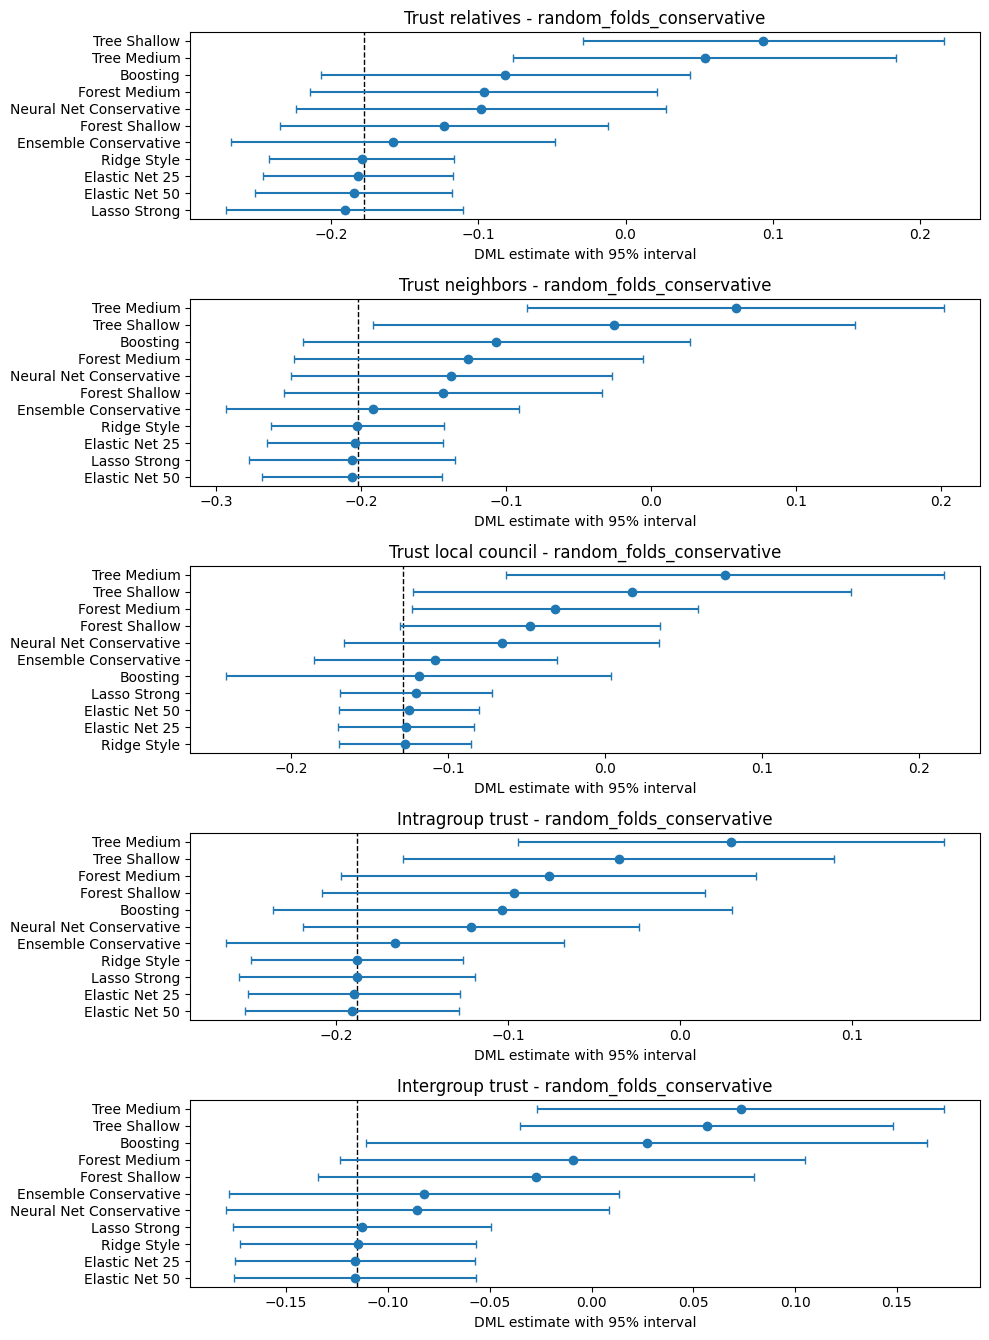

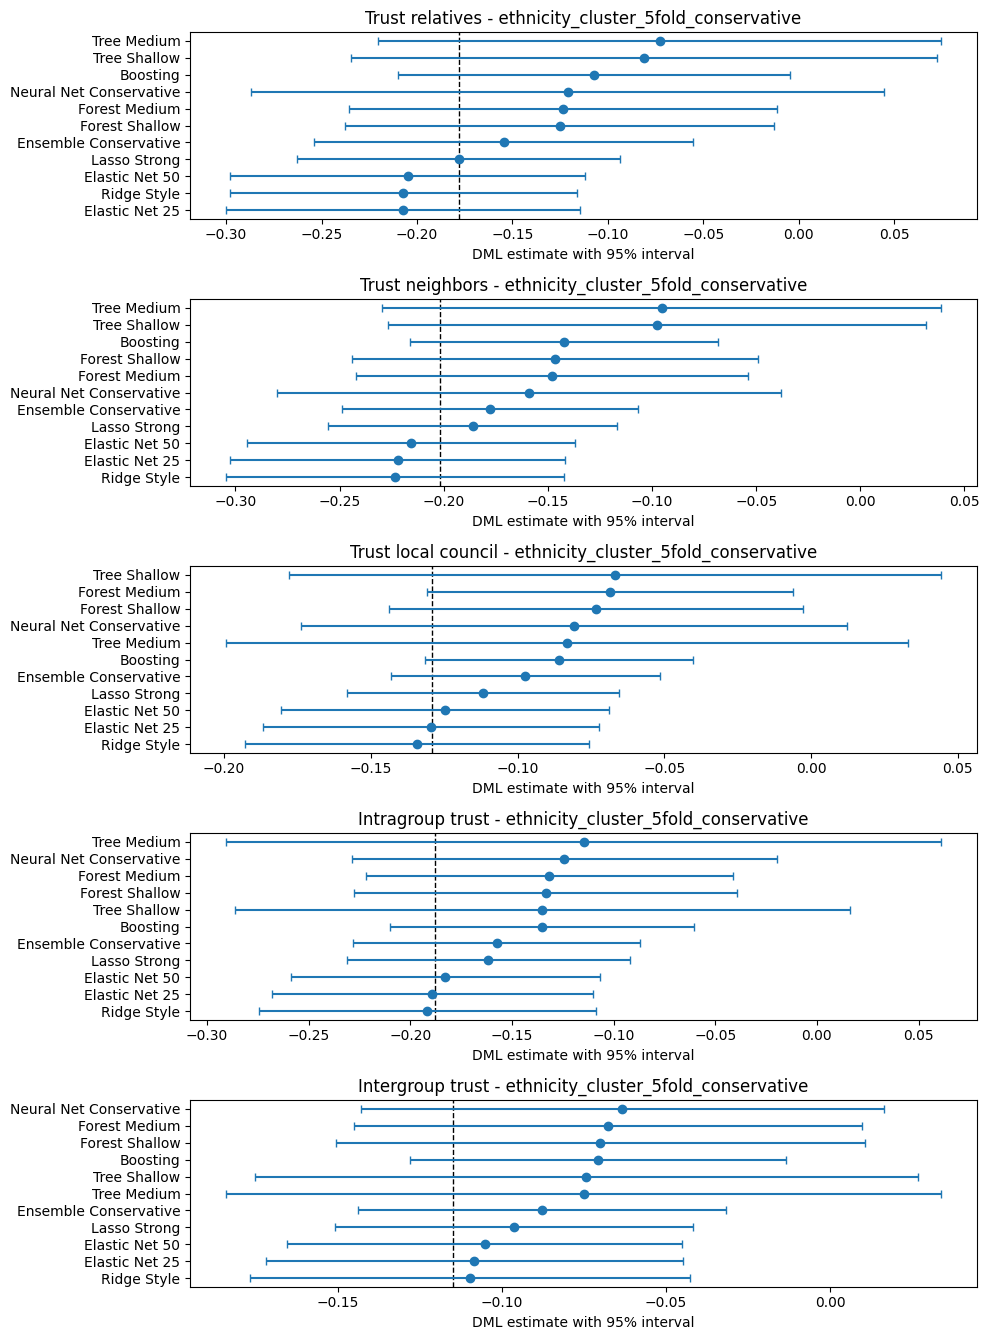

In [53]:
plot_data = table3_sensitivity_results_long.copy()
if plot_data.empty:
    raise ValueError("Run or load Table 3 sensitivity results before plotting.")

for design_name in plot_data["crossfit_design"].unique():
    design_data = plot_data.loc[plot_data["crossfit_design"] == design_name].copy()
    fig, axes = plt.subplots(len(outcomes), 1, figsize=(10, 2.7 * len(outcomes)), sharex=False)
    if len(outcomes) == 1:
        axes = [axes]
    for ax, outcome in zip(axes, outcomes):
        sub = design_data.loc[design_data["outcome"] == outcome].sort_values("theta")
        ax.axvline(original_ols[outcome], color="black", linestyle="--", linewidth=1, label="Original OLS")
        ax.errorbar(sub["theta"], sub["learner"], xerr=1.96 * sub["se"], fmt="o", capsize=3)
        ax.set_title(f"{outcome_labels[outcome]} - {design_name}")
        ax.set_xlabel("DML estimate with 95% interval")
    plt.tight_layout()
    plt.show()